# **DATA ANALYSIS**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# importing neccesary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# loading the cleaned dataset
main_df = pd.read_csv('/content/drive/MyDrive/FINAL DSPL Datasets/new cleaned dataset recent/train_data_cleaned_V1_EDA (2).csv')

In [ ]:
main_df

,Reservation-id,Gender,Age,Ethnicity,Educational_Level,Income,Country_region,Hotel_Type,Expected_checkin,Expected_checkout,...,Reservation_Status,Use_Promotion,Discount_Rate,Room_Rate,Lead_Time,Total Nights,Checkin_Month,Checkin_Day_of_Week,Is_Weekend,Total_Guests
0,39428300,F,40,Latino,Grad,<25K,North,City Hotel,2015-07-01,2015-07-02,...,Check-Out,Yes,10,218,41,1,7,2,0,4
1,77222321,F,62,Latino,High-School,25K --50K,East,Resort,2015-07-03,2015-07-04,...,Check-Out,Yes,10,242,13,1,7,4,0,2
2,7647912,M,40,Latino,Mid-School,>100K,North,City Hotel,2015-07-03,2015-07-04,...,Check-Out,No,0,170,8,1,7,4,0,3
3,94296865,M,59,African American,Mid-School,>100K,West,Resort,2015-05-06,2015-05-07,...,Check-Out,Yes,10,245,84,1,5,2,0,5
4,93087487,M,21,Latino,Grad,50K -- 100K,West,City Hotel,2015-04-22,2015-04-25,...,Check-Out,Yes,20,212,72,3,4,2,0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22692,15645505,F,49,African American,Mid-School,<25K,West,City Hotel,2016-08-31,2016-09-01,...,Check-Out,Yes,10,100,37,1,8,2,0,4
22693,56414525,F,49,Asian American,College,25K --50K,South,Airport Hotels,2016-08-31,2016-09-01,...,No-Show,Yes,40,194,127,1,8,2,0,3
22694,52023375,F,49,Latino,High-School,50K -- 100K,South,Airport Hotels,2016-09-01,2016-09-02,...,Check-Out,Yes,5,202,9,1,9,3,0,4
22695,98041387,M,65,African American,College,25K --50K,South,Airport Hotels,2016-08-31,2016-09-01,...,Canceled,Yes,20,157,98,1,8,2,0,5


In [ ]:
# checking the data types

main_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22697 entries, 0 to 22696
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Reservation-id          22697 non-null  int64 
 1   Gender                  22697 non-null  object
 2   Age                     22697 non-null  int64 
 3   Ethnicity               22697 non-null  object
 4   Educational_Level       22697 non-null  object
 5   Income                  22697 non-null  object
 6   Country_region          22697 non-null  object
 7   Hotel_Type              22697 non-null  object
 8   Expected_checkin        22697 non-null  object
 9   Expected_checkout       22697 non-null  object
 10  Booking_date            22697 non-null  object
 11  Adults                  22697 non-null  int64 
 12  Children                22697 non-null  int64 
 13  Babies                  22697 non-null  int64 
 14  Meal_Type               22697 non-null  object
 15  Vi

In [ ]:
# Define the mapping for Reservation_Status
status_mapping = {
    'Check-Out': 1,
    'Canceled': 2,
    'No-Show': 3
}

# Apply the mapping to create a new encoded column
main_df['Reservation_Status_Encoded'] = main_df['Reservation_Status'].map(status_mapping)

# Display the first few rows with the new encoded column and its data type to verify
display(main_df[['Reservation_Status', 'Reservation_Status_Encoded']].head())
print(f"Data type of Reservation_Status_Encoded: {main_df['Reservation_Status_Encoded'].dtype}")

,Reservation_Status,Reservation_Status_Encoded
0,Check-Out,1
1,Check-Out,1
2,Check-Out,1
3,Check-Out,1
4,Check-Out,1


Data type of Reservation_Status_Encoded: int64


In [ ]:
# Select only numerical columns
numerical_cols = main_df.select_dtypes(include=['number']).columns

# Generate descriptive statistics for numerical features
numerical_summary = main_df[numerical_cols].describe()

display(numerical_summary)

,Reservation-id,Age,Adults,Children,Babies,Discount_Rate,Room_Rate,Lead_Time,Total Nights,Checkin_Month,Checkin_Day_of_Week,Is_Weekend,Total_Guests,Reservation_Status_Encoded
count,2.269700e+04,22697.000000,22697.000000,22697.000000,22697.000000,22697.000000,22697.000000,22697.000000,22697.000000,22697.000000,22697.000000,22697.000000,22697.000000,22697.000000
mean,5.002841e+07,43.958188,1.952329,1.671851,0.349826,12.495264,175.244482,112.348813,1.827114,6.237608,2.849011,0.247213,3.974005,1.307970
std,2.888814e+07,15.292601,0.789159,0.696052,0.572409,11.184882,43.929933,77.138738,0.980727,3.305431,2.000436,0.431401,1.102371,0.606672
min,3.154000e+03,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,0.000000,1.000000,1.000000,0.000000,0.000000,2.000000,1.000000
25%,2.504788e+07,31.000000,1.000000,1.000000,0.000000,5.000000,137.000000,48.000000,1.000000,3.000000,1.000000,0.000000,3.000000,1.000000
50%,4.993973e+07,44.000000,2.000000,2.000000,0.000000,10.000000,175.000000,104.000000,1.000000,6.000000,3.000000,0.000000,4.000000,1.000000
75%,7.508055e+07,57.000000,2.000000,2.000000,1.000000,20.000000,214.000000,167.000000,2.000000,9.000000,4.000000,0.000000,5.000000,1.000000
max,9.999900e+07,70.000000,4.000000,3.000000,2.000000,40.000000,250.000000,541.000000,4.000000,12.000000,6.000000,1.000000,7.000000,3.000000


In [ ]:
# Select only categorical columns
categorical_cols = main_df.select_dtypes(include=['object']).columns

# Generate descriptive statistics for categorical features
categorical_summary = main_df[categorical_cols].describe()

display(categorical_summary)

,Gender,Ethnicity,Educational_Level,Income,Country_region,Hotel_Type,Expected_checkin,Expected_checkout,Booking_date,Meal_Type,Visted_Previously,Previous_Cancellations,Deposit_type,Booking_channel,Required_Car_Parking,Reservation_Status,Use_Promotion
count,22697,22697,22697,22697,22697,22697,22697,22697,22697,22697,22697,22697,22697,22697,22697,22697,22697
unique,2,4,4,4,4,3,897,925,1108,3,2,2,3,3,2,3,2
top,F,African American,College,50K -- 100K,South,Airport Hotels,2016-02-09,2016-02-10,2015-10-19,BB,No,No,No Deposit,Online,Yes,Check-Out,Yes
freq,11410,5750,9153,6568,9099,7645,128,78,196,11643,15077,20088,15099,12905,16193,17465,17072


EDA

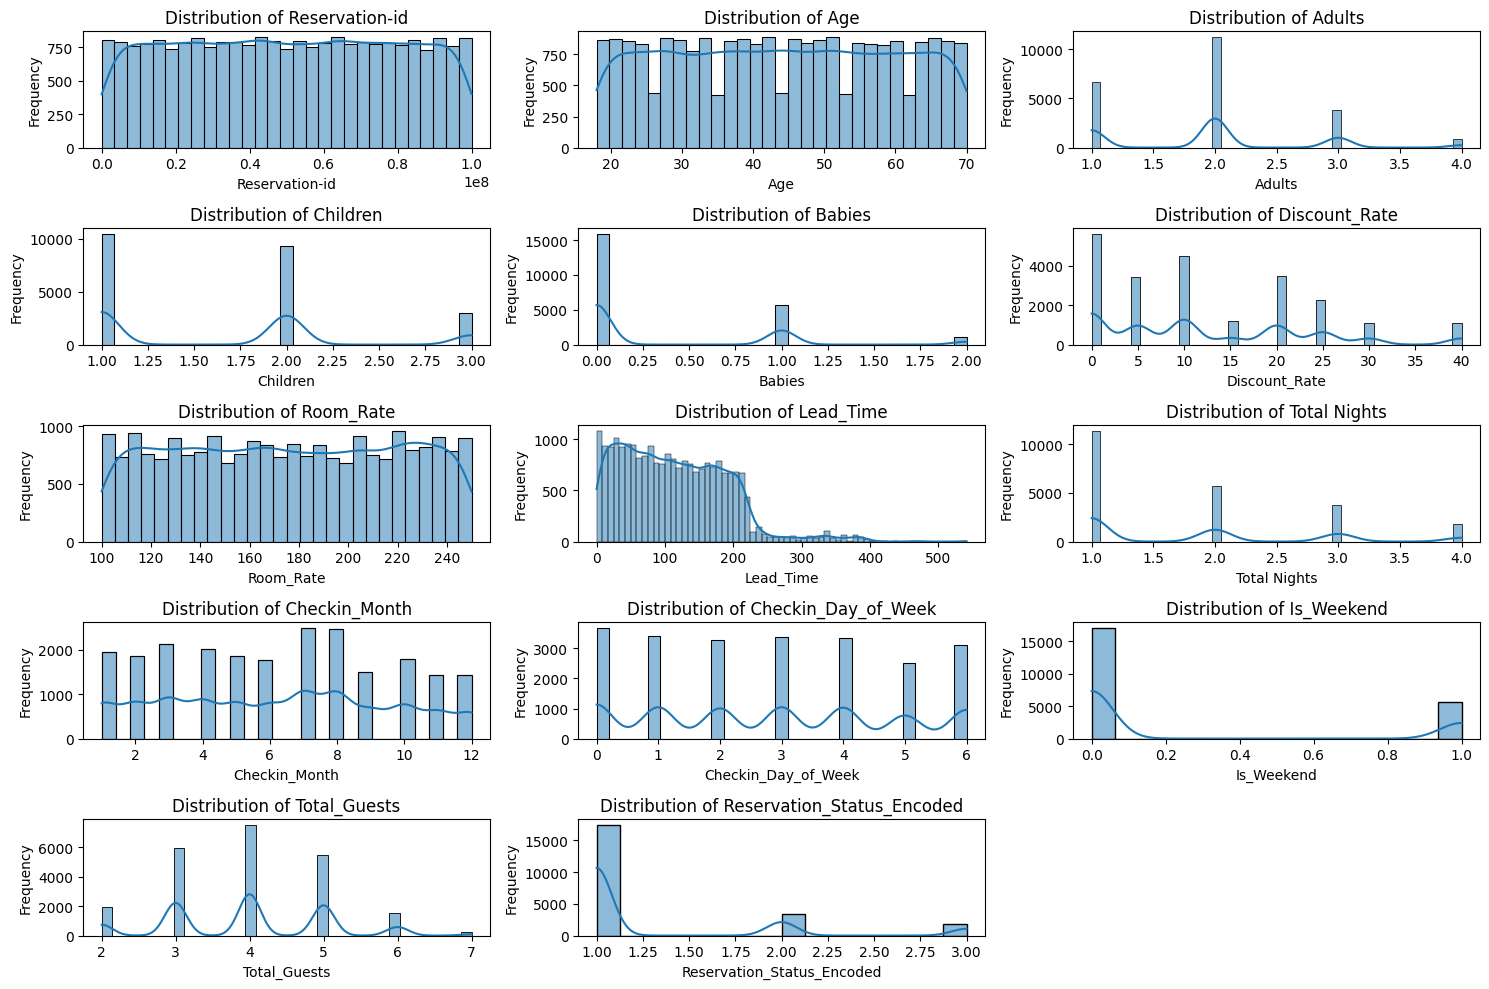

In [ ]:
# Univariate distribution of each numerical variable
plt.figure(figsize=(15, 10))
num_plots = len(numerical_cols)
num_rows = (num_plots // 3) + (1 if num_plots % 3 > 0 else 0)

for i, col in enumerate(numerical_cols):
    plt.subplot(num_rows, 3, i + 1)
    sns.histplot(main_df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

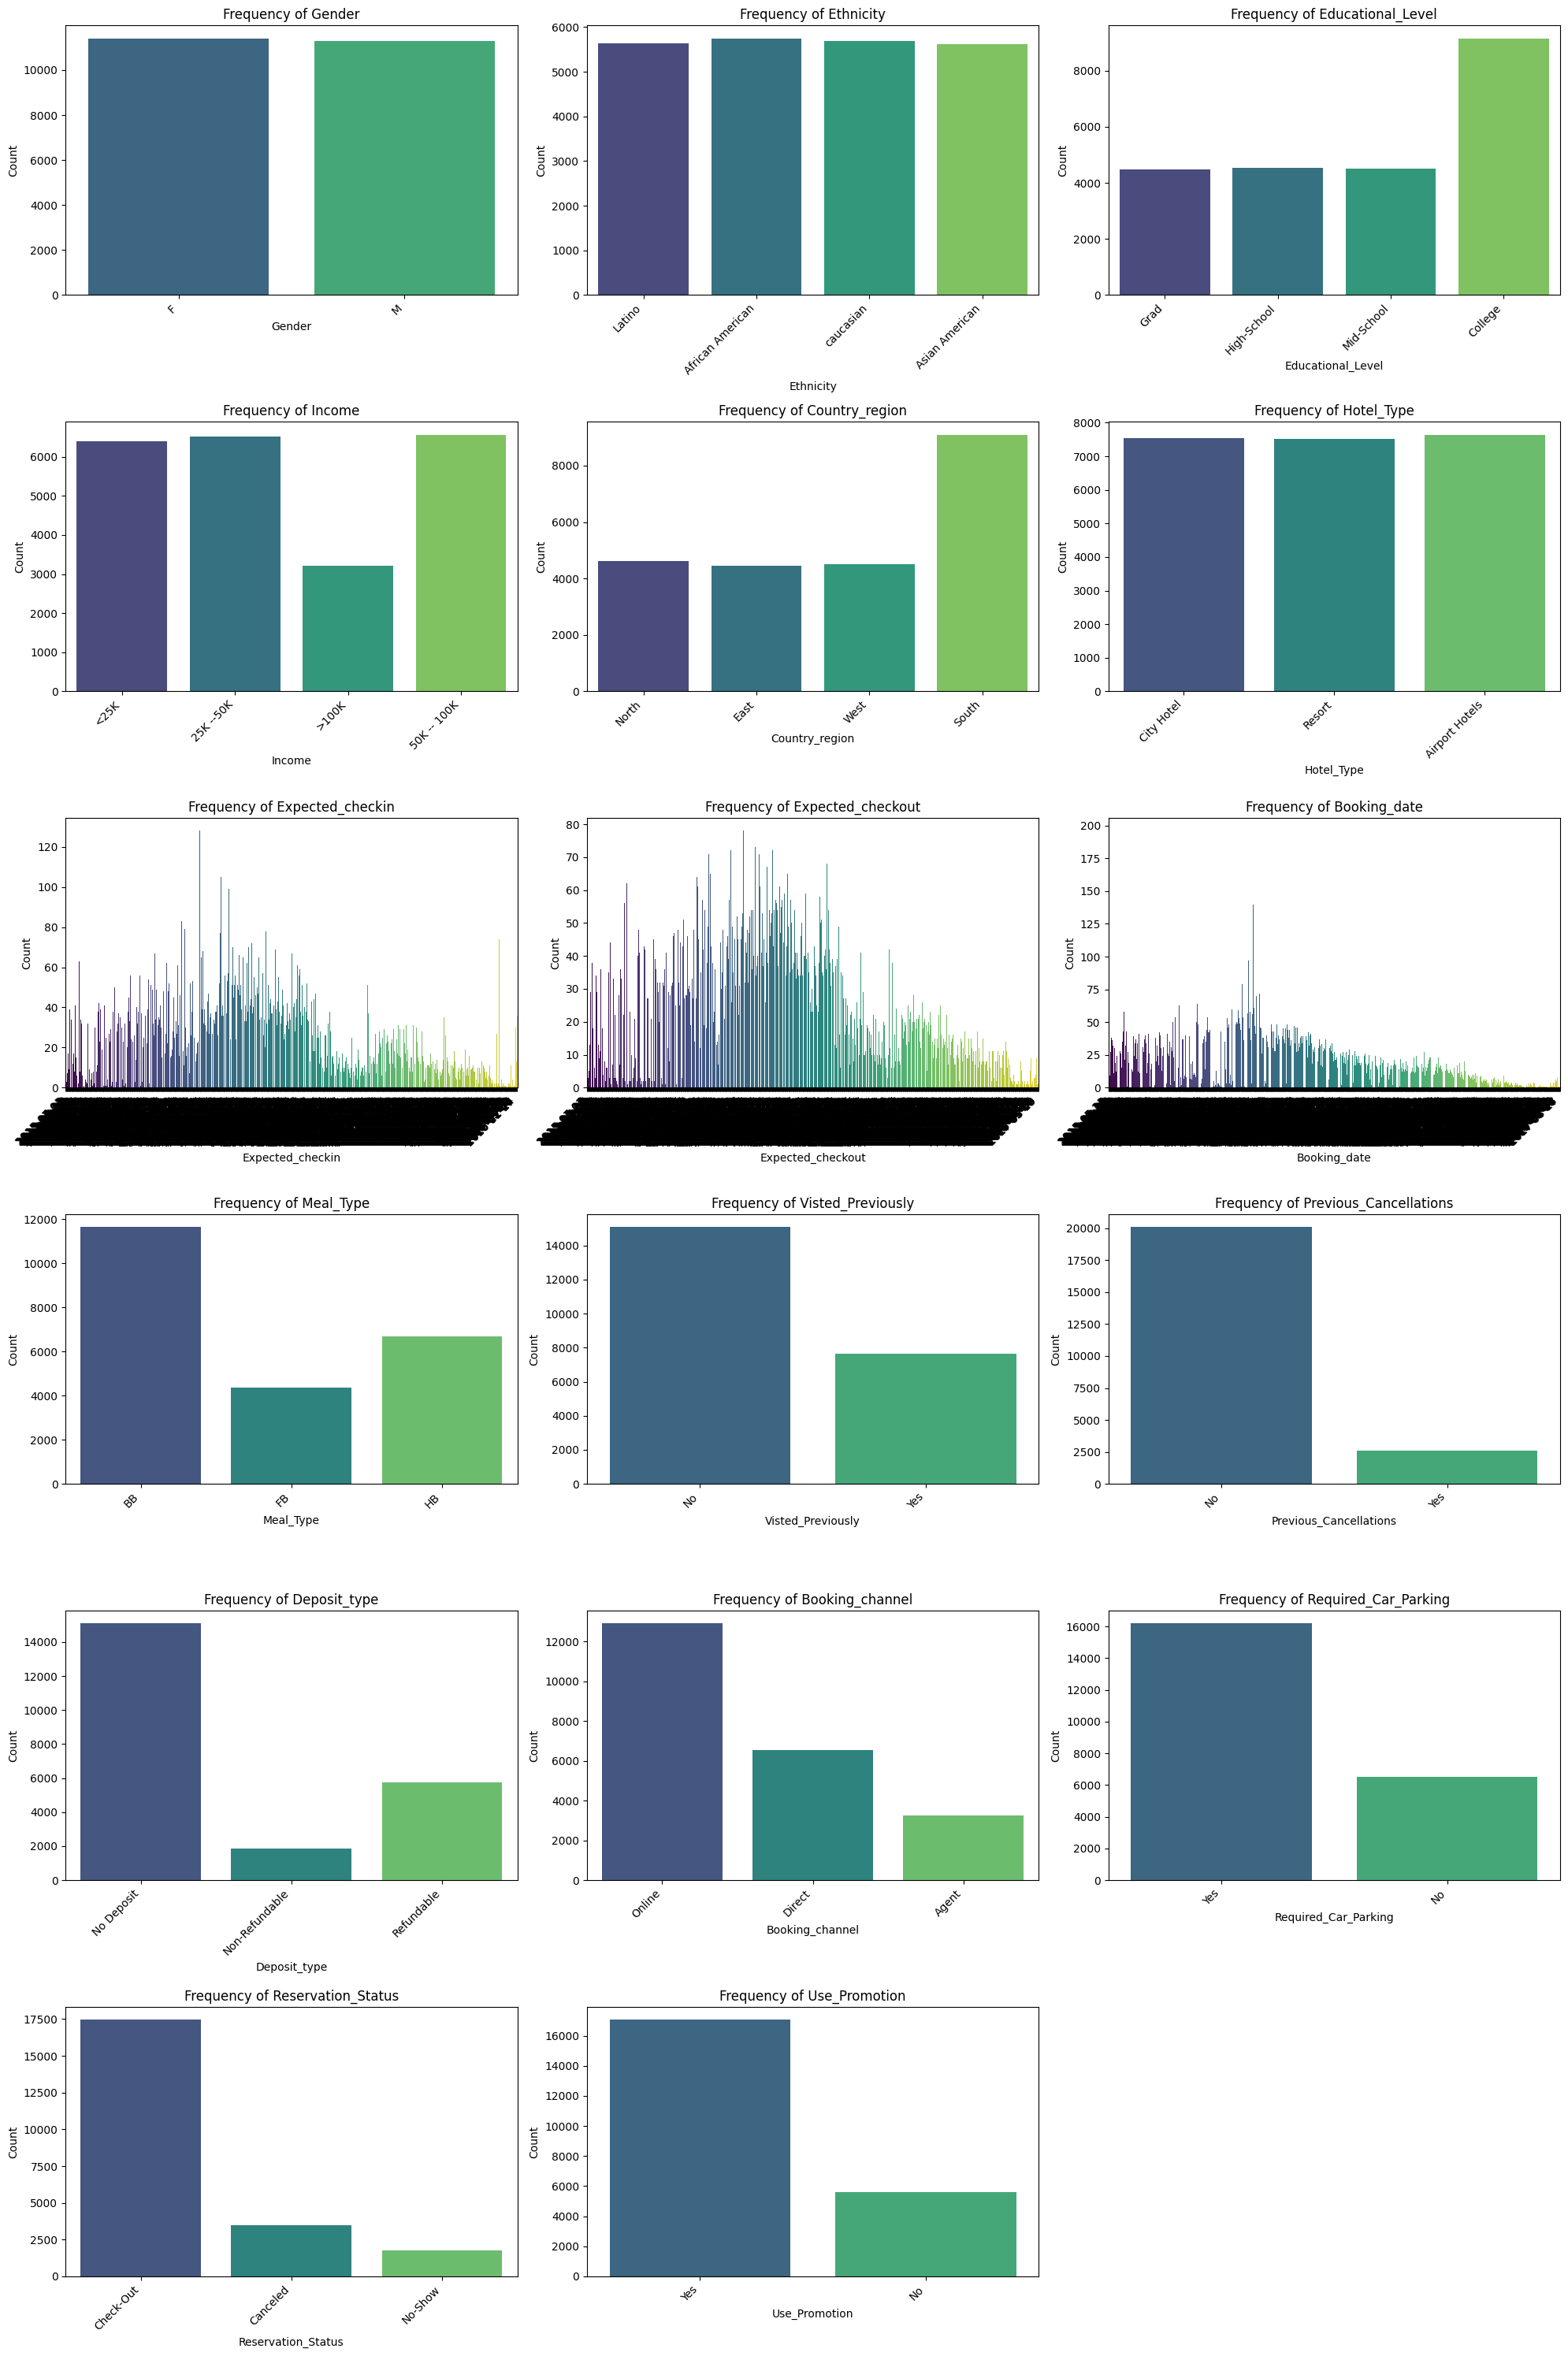

In [ ]:
# Univariate distribution of each categorical variable
plt.figure(figsize=(20, 30))
num_plots = len(categorical_cols)
num_rows = (num_plots // 3) + (1 if num_plots % 3 > 0 else 0)

for i, col in enumerate(categorical_cols):
    plt.subplot(num_rows, 3, i + 1)
    sns.countplot(data=main_df, x=col, hue=col, palette='viridis', legend=False)
    plt.title(f'Frequency of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability

plt.tight_layout()
plt.show()

# Hypothesis Testing with Visualisations

In [ ]:
# Create a new DataFrame by filtering for Reservation_Status_Encoded values 2 (Canceled) and 3 (No-Show)
canceled_no_show_df = main_df[main_df['Reservation_Status_Encoded'].isin([2, 3])]

# Display the first few rows of the new DataFrame to verify the filter
display(canceled_no_show_df.head())

# Print the value counts to confirm only statuses 2 and 3 are present
print("Value counts for Reservation_Status_Encoded in the new DataFrame:")
display(canceled_no_show_df['Reservation_Status_Encoded'].value_counts())

,Reservation-id,Gender,Age,Ethnicity,Educational_Level,Income,Country_region,Hotel_Type,Expected_checkin,Expected_checkout,...,Use_Promotion,Discount_Rate,Room_Rate,Lead_Time,Total Nights,Checkin_Month,Checkin_Day_of_Week,Is_Weekend,Total_Guests,Reservation_Status_Encoded
10413,65894391,M,44,African American,College,>100K,South,City Hotel,2017-05-13,2017-05-15,...,Yes,10,115,82,2,5,5,1,4,2
10414,49370462,F,40,African American,College,>100K,South,City Hotel,2016-09-26,2016-09-28,...,Yes,15,122,21,2,9,0,0,3,3
10421,52406663,F,41,caucasian,College,>100K,West,City Hotel,2017-01-21,2017-01-22,...,Yes,20,112,109,1,1,5,1,5,2
10423,58969044,M,24,Latino,Grad,25K --50K,East,City Hotel,2017-07-06,2017-07-07,...,Yes,20,160,194,1,7,3,0,4,2
10425,77884516,F,28,caucasian,College,50K -- 100K,South,Airport Hotels,2017-07-19,2017-07-20,...,No,0,209,75,1,7,2,0,3,2


Value counts for Reservation_Status_Encoded in the new DataFrame:


,count
Reservation_Status_Encoded,
2,3474
3,1758


# RESERVATION STATUS CONTRIBUTION OF TOTAL BOOKINGS

/tmp/ipykernel_3599/3356868780.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Reservation_Status_Label', y='Proportion_Percentage', data=status_proportions,


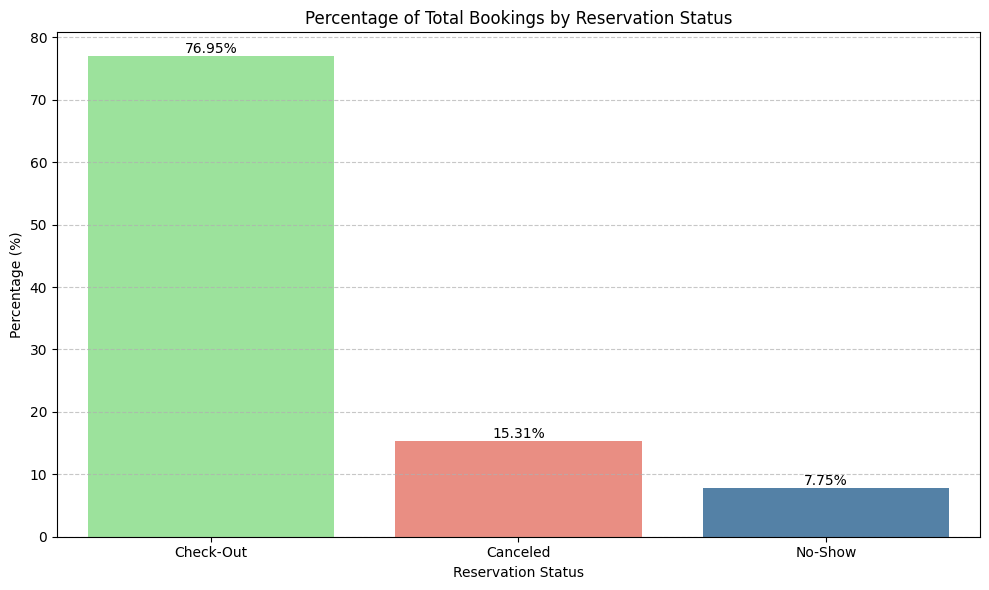

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the proportion of each reservation status
status_proportions = main_df['Reservation_Status_Encoded'].value_counts(normalize=True).mul(100).reset_index()
status_proportions.columns = ['Reservation_Status_Encoded', 'Proportion_Percentage']

# Define the status_labels dictionary for meaningful labels
status_labels = {
    1: 'Check-Out',
    2: 'Canceled',
    3: 'No-Show'
}

# Map the encoded status to readable labels for plotting
status_proportions['Reservation_Status_Label'] = status_proportions['Reservation_Status_Encoded'].map(status_labels)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Reservation_Status_Label', y='Proportion_Percentage', data=status_proportions,
            palette={'Check-Out': 'lightgreen', 'Canceled': 'salmon', 'No-Show': 'steelblue'})

# Add percentage labels on top of the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%')

plt.title('Percentage of Total Bookings by Reservation Status')
plt.xlabel('Reservation Status')
plt.ylabel('Percentage (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# first hypothesis
# Rerservation Status Vs Education

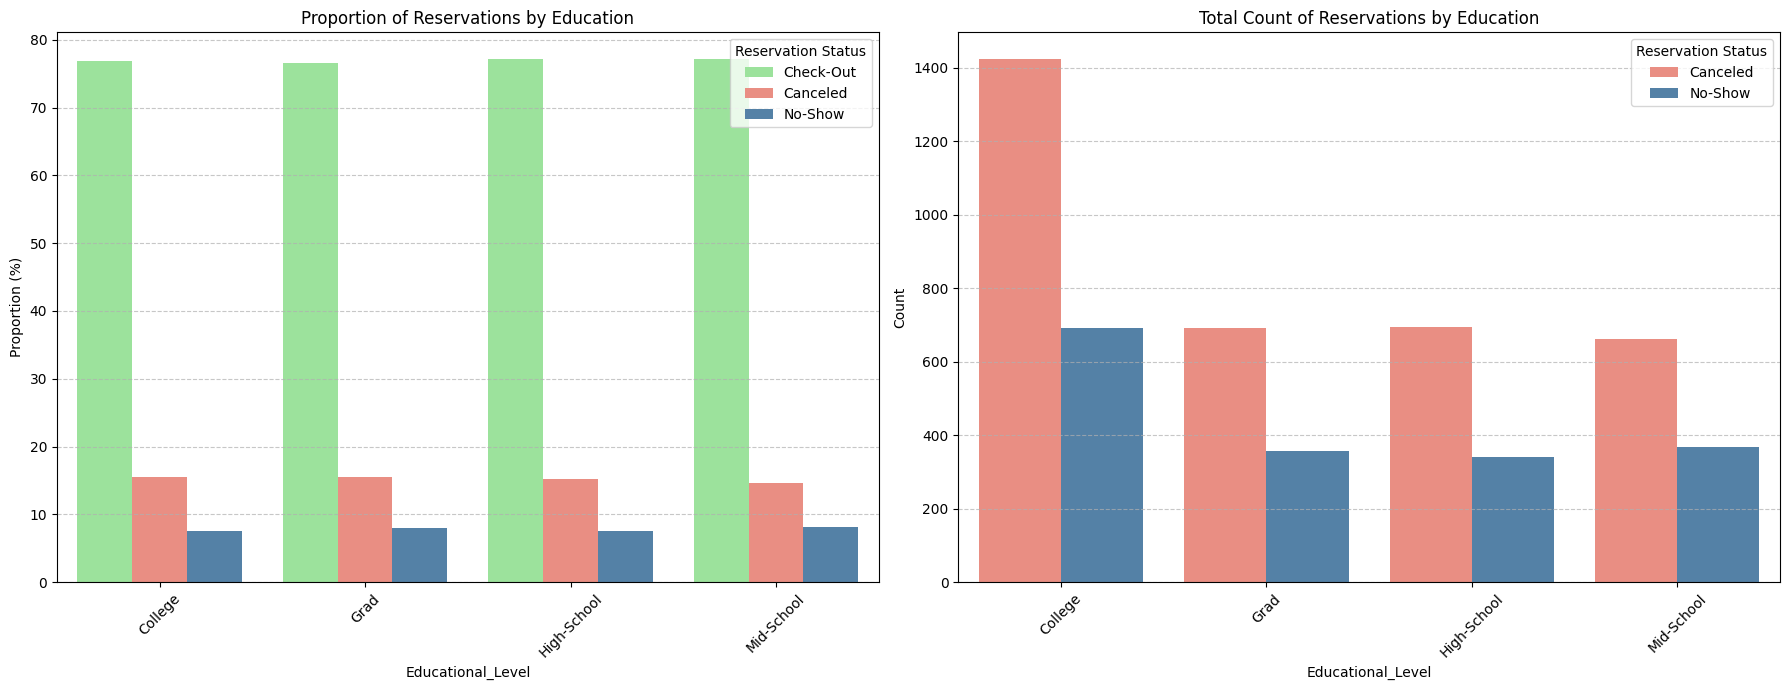

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare Proportion Data (as per your original logic)
status_education_proportions = (
    main_df.groupby('Educational_Level')['Reservation_Status_Encoded']
    .value_counts(normalize=True)
    .mul(100)
    .rename('Proportion_Percentage')
    .reset_index()
)

# 2. Create the figure with 2 subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- PLOT 1: PROPORTIONS (Left) ---
sns.barplot(data=status_education_proportions,
            x='Educational_Level',
            y='Proportion_Percentage',
            hue='Reservation_Status_Encoded',
            palette={1: 'lightgreen', 2: 'salmon', 3: 'steelblue'}, # Added color for status 1
            ax=axes[0])

axes[0].set_title('Proportion of Reservations by Education')
axes[0].set_ylabel('Proportion (%)')
axes[0].tick_params(axis='x', rotation=45)

# --- PLOT 2: RAW COUNTS (Right) ---
sns.countplot(data=canceled_no_show_df,
              x='Educational_Level',
              hue='Reservation_Status_Encoded',
              palette={2: 'salmon', 3: 'steelblue'},
              ax=axes[1])

axes[1].set_title('Total Count of Reservations by Education')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

# 3. Uniform Legend Handling for both plots
# Updated new_labels_map to include status 1 for the first plot's legend if it were to be handled by this loop
new_labels_map = {1: 'Check-Out', 2: 'Canceled', 3: 'No-Show'}

for ax in axes:
    handles, labels = ax.get_legend_handles_labels()
    # Map the labels based on the dictionary
    mapped_labels = [new_labels_map[int(float(label))] for label in labels]
    ax.legend(handles, mapped_labels, title='Reservation Status')
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# second hypothesis
# Rerservation Status Vs Income


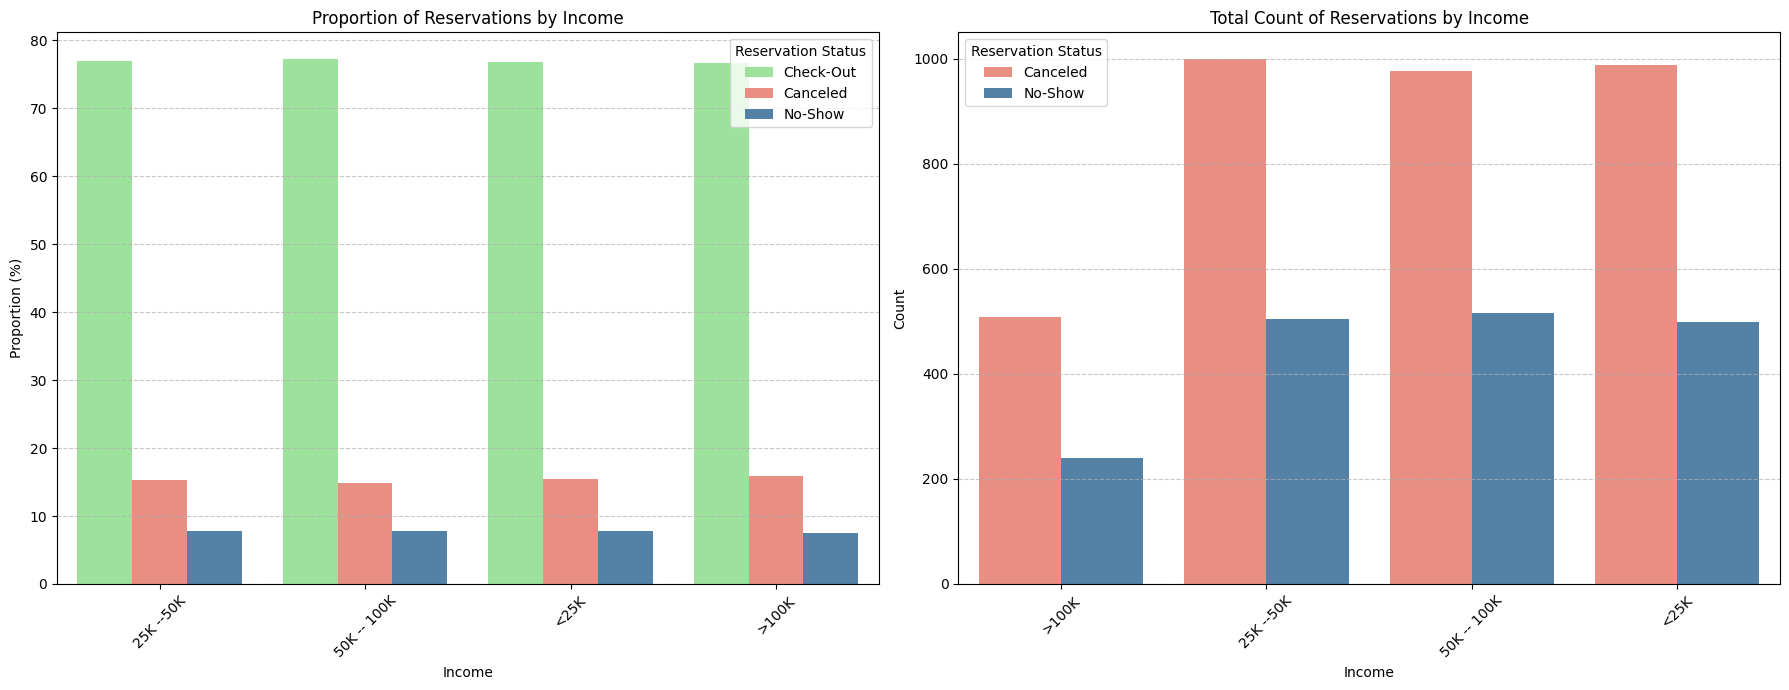

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare Proportion Data (as per your original logic)
status_education_proportions = (
    main_df.groupby('Income')['Reservation_Status_Encoded']
    .value_counts(normalize=True)
    .mul(100)
    .rename('Proportion_Percentage')
    .reset_index()
)

# 2. Create the figure with 2 subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- PLOT 1: PROPORTIONS (Left) ---
sns.barplot(data=status_education_proportions,
            x='Income',
            y='Proportion_Percentage',
            hue='Reservation_Status_Encoded',
            palette={1: 'lightgreen', 2: 'salmon', 3: 'steelblue'}, # Added color for status 1
            ax=axes[0])

axes[0].set_title('Proportion of Reservations by Income')
axes[0].set_ylabel('Proportion (%)')
axes[0].tick_params(axis='x', rotation=45)

# --- PLOT 2: RAW COUNTS (Right) ---
sns.countplot(data=canceled_no_show_df,
              x='Income',
              hue='Reservation_Status_Encoded',
              palette={2: 'salmon', 3: 'steelblue'},
              ax=axes[1])

axes[1].set_title('Total Count of Reservations by Income')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

# 3. Uniform Legend Handling for both plots
# Updated new_labels_map to include status 1 for the first plot's legend if it were to be handled by this loop
new_labels_map = {1: 'Check-Out', 2: 'Canceled', 3: 'No-Show'}

for ax in axes:
    handles, labels = ax.get_legend_handles_labels()
    # Map the labels based on the dictionary
    mapped_labels = [new_labels_map[int(float(label))] for label in labels]
    ax.legend(handles, mapped_labels, title='Reservation Status')
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# third hypothesis
# Rerservation Status Vs Deposit Type

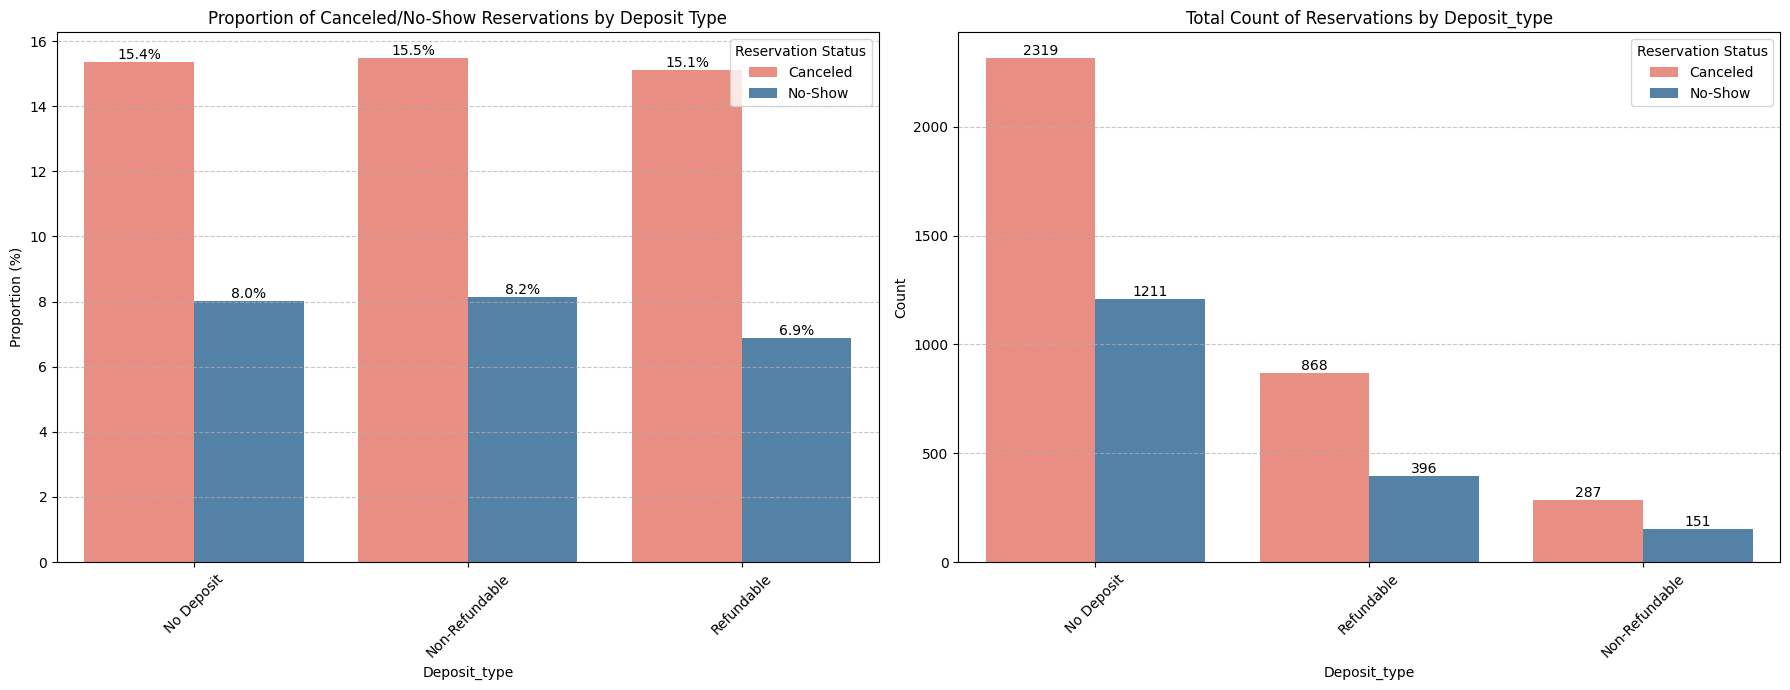

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare Proportion Data (as per your original logic)
status_education_proportions = (
    main_df.groupby('Deposit_type')['Reservation_Status_Encoded']
    .value_counts(normalize=True)
    .mul(100) # Convert to percentage
    .rename('Proportion_Percentage') # Rename the series
    .reset_index() # Convert series to DataFrame
)
# Filter out Check-Out (status 1) for plotting proportions
status_education_proportions_filtered = status_education_proportions[status_education_proportions['Reservation_Status_Encoded'].isin([2, 3])]

# 2. Create the figure with 2 subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- PLOT 1: PROPORTIONS (Left) ---
sns.barplot(data=status_education_proportions_filtered,
            x='Deposit_type',
            y='Proportion_Percentage',
            hue='Reservation_Status_Encoded',
            palette={2: 'salmon', 3: 'steelblue'}, # Only include colors for Canceled and No-Show
            ax=axes[0])

axes[0].set_title('Proportion of Canceled/No-Show Reservations by Deposit Type')
axes[0].set_ylabel('Proportion (%)')
axes[0].tick_params(axis='x', rotation=45)
# Add values on top of each bar for the first plot
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.1f%%')

# --- PLOT 2: RAW COUNTS (Right) ---
sns.countplot(data=canceled_no_show_df,
              x='Deposit_type',
              hue='Reservation_Status_Encoded',
              palette={2: 'salmon', 3: 'steelblue'},
              ax=axes[1])

axes[1].set_title('Total Count of Reservations by Deposit_type')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)
# Add values on top of each bar for the second plot
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%d')

# 3. Uniform Legend Handling for both plots
new_labels_map = {1: 'Check-Out', 2: 'Canceled', 3: 'No-Show'}

for ax in axes:
    handles, labels = ax.get_legend_handles_labels()
    # Map the labels based on the dictionary
    # Filter labels to only include those present in the plot (2 and 3)
    mapped_labels = [new_labels_map[int(float(label))] for label in labels if int(float(label)) in [2, 3]]
    # Filter handles to match mapped_labels
    filtered_handles = [h for h, l in zip(handles, labels) if int(float(l)) in [2, 3]]
    ax.legend(filtered_handles, mapped_labels, title='Reservation Status')
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# fourth hypothesis Lead Time vs Reservations


/tmp/ipykernel_3599/133059737.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp_df.groupby('Lead_Time_Bracket')['Reservation_Status_Encoded']


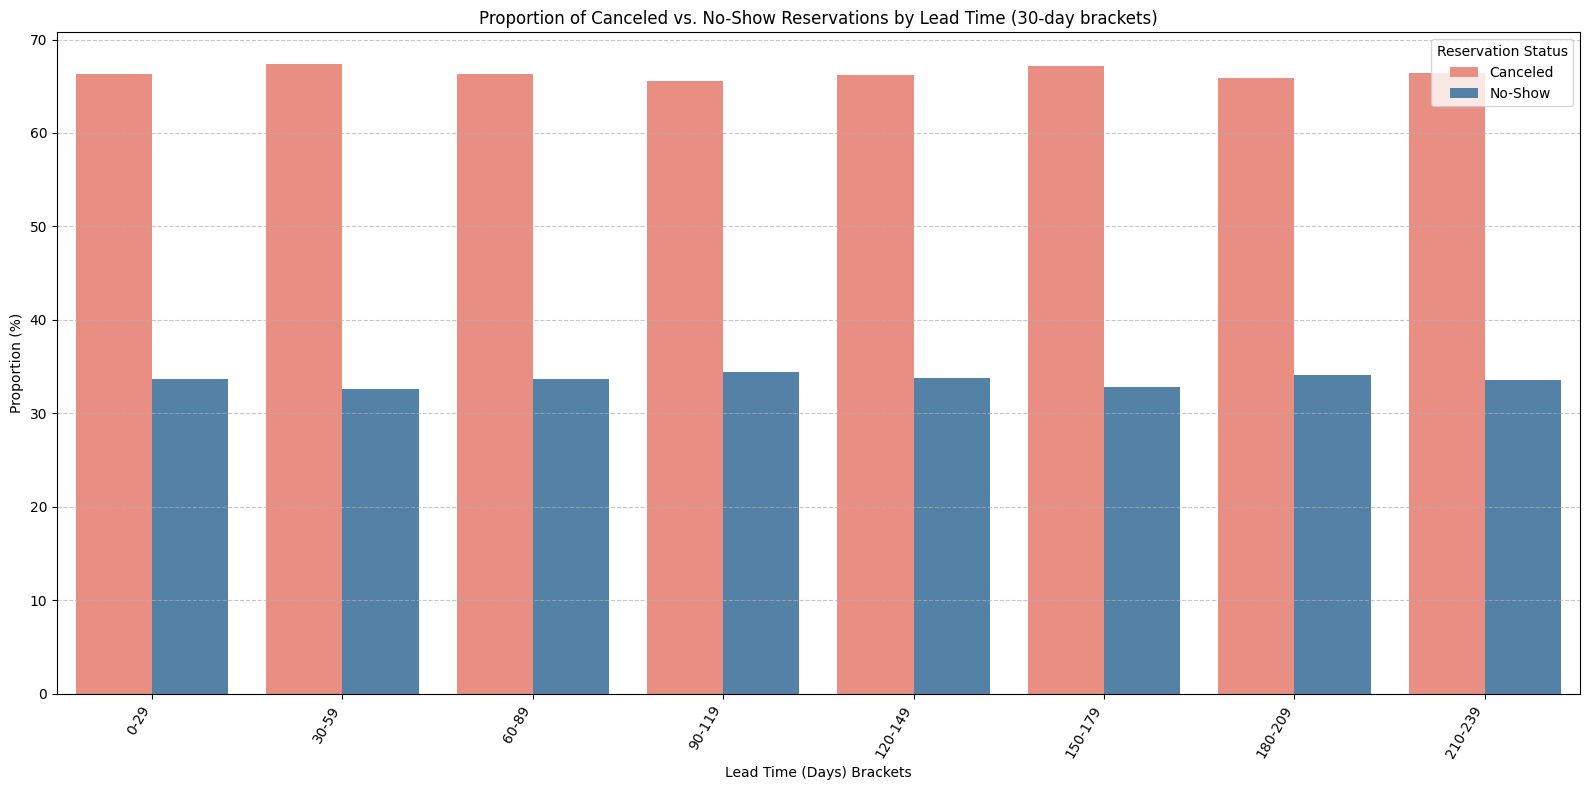

In [ ]:
# Determine the maximum Lead_Time to set the bins
max_lead_time = canceled_no_show_df['Lead_Time'].max()

# Create fixed-width bins for Lead_Time (30-day brackets)
# Add a small epsilon to max_lead_time to ensure the largest value is included
bins = list(range(0, int(max_lead_time) + 31, 30))
labels = ['{}-{}'.format(i, i+29) for i in bins[:-1]]

# Create a copy to avoid SettingWithCopyWarning and add the Lead_Time_Bracket column
temp_df = canceled_no_show_df.copy()
temp_df['Lead_Time_Bracket'] = pd.cut(
    temp_df['Lead_Time'],
    bins=bins,
    labels=labels,
    right=False, # Interval is [a, b) except for the last bin if right=True is used implicitly. Right=False means [a,b)
    include_lowest=True
)

# Calculate proportions of each Reservation_Status_Encoded within each Lead_Time_Bracket
status_lead_time_proportions_brackets = (
    temp_df.groupby('Lead_Time_Bracket')['Reservation_Status_Encoded']
    .value_counts(normalize=True)
    .mul(100) # Convert to percentage
    .rename('Proportion_Percentage') # Rename the series
    .reset_index() # Convert series to DataFrame
)

plt.figure(figsize=(16, 8))
sns.barplot(data=status_lead_time_proportions_brackets,
            x='Lead_Time_Bracket',
            y='Proportion_Percentage',
            hue='Reservation_Status_Encoded',
            palette={2: 'salmon', 3: 'steelblue'}) # Custom colors for 'Canceled' and 'No-Show'

plt.title('Proportion of Canceled vs. No-Show Reservations by Lead Time (30-day brackets)')
plt.xlabel('Lead Time (Days) Brackets')
plt.ylabel('Proportion (%)')
plt.xticks(rotation=60, ha='right')

# Create a custom legend for Reservation_Status_Encoded to show meaningful labels
handles, labels = plt.gca().get_legend_handles_labels()
new_labels_map = {2: 'Canceled', 3: 'No-Show'}
legend_labels_mapped = [new_labels_map[int(label)] for label in labels]
plt.legend(handles, legend_labels_mapped, title='Reservation Status')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Fifth hypothesis visited previously with reservations

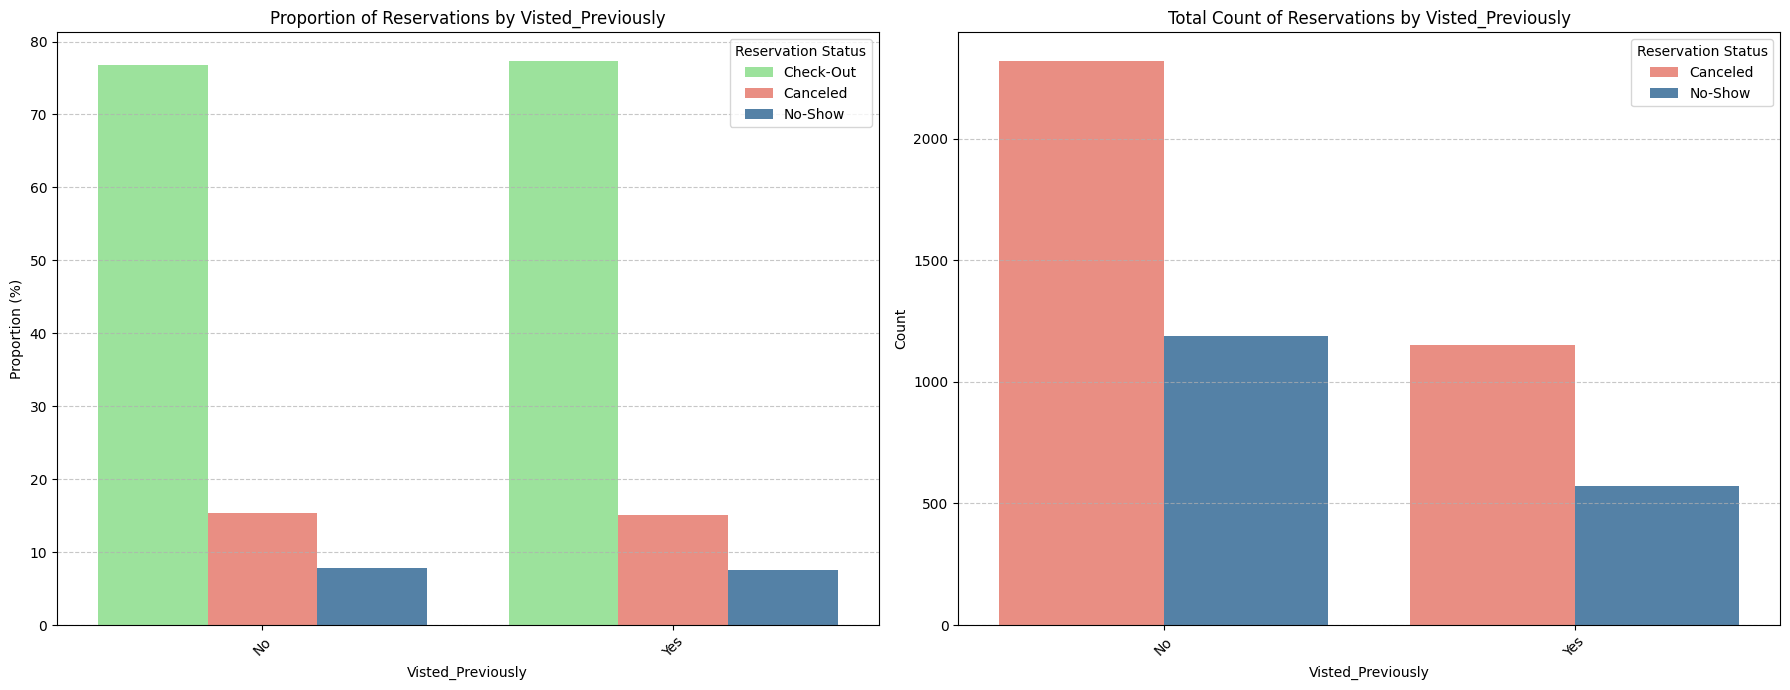

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare Proportion Data (as per your original logic)
status_education_proportions = (
    main_df.groupby('Visted_Previously')['Reservation_Status_Encoded']
    .value_counts(normalize=True)
    .mul(100)
    .rename('Proportion_Percentage')
    .reset_index()
)

# 2. Create the figure with 2 subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- PLOT 1: PROPORTIONS (Left) ---
sns.barplot(data=status_education_proportions,
            x='Visted_Previously',
            y='Proportion_Percentage',
            hue='Reservation_Status_Encoded',
            palette={1: 'lightgreen', 2: 'salmon', 3: 'steelblue'}, # Added color for status 1
            ax=axes[0])

axes[0].set_title('Proportion of Reservations by Visted_Previously')
axes[0].set_ylabel('Proportion (%)')
axes[0].tick_params(axis='x', rotation=45)

# --- PLOT 2: RAW COUNTS (Right) ---
sns.countplot(data=canceled_no_show_df,
              x='Visted_Previously',
              hue='Reservation_Status_Encoded',
              palette={2: 'salmon', 3: 'steelblue'},
              ax=axes[1])

axes[1].set_title('Total Count of Reservations by Visted_Previously')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

# 3. Uniform Legend Handling for both plots
# Updated new_labels_map to include status 1 for the first plot's legend if it were to be handled by this loop
new_labels_map = {1: 'Check-Out', 2: 'Canceled', 3: 'No-Show'}

for ax in axes:
    handles, labels = ax.get_legend_handles_labels()
    # Map the labels based on the dictionary
    mapped_labels = [new_labels_map[int(float(label))] for label in labels]
    ax.legend(handles, mapped_labels, title='Reservation Status')
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# 6th hypothesis is discount rate vs reservation status

/tmp/ipykernel_3599/3609068959.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp_df_discount.groupby('Discount_Rate_Category')['Reservation_Status_Encoded']


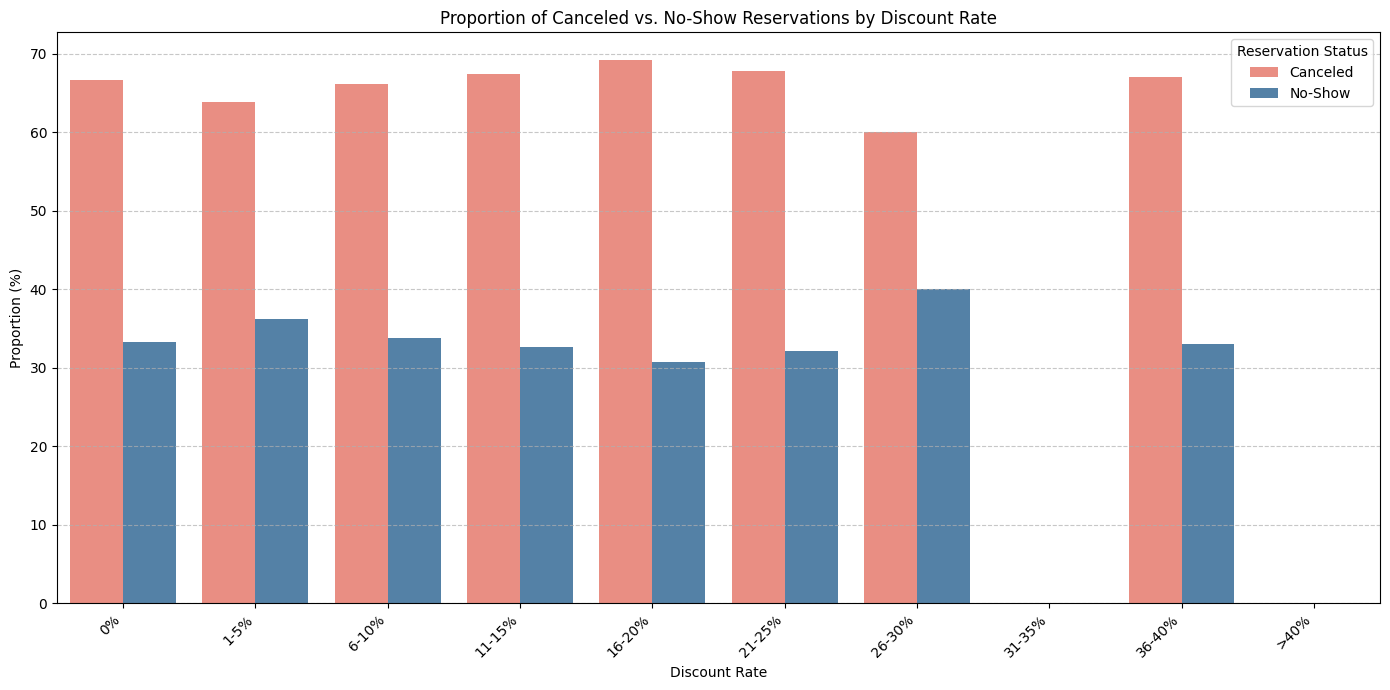

In [ ]:
# Define custom bins for Discount_Rate to group similar rates
bins = [-1, 0, 5, 10, 15, 20, 25, 30, 35, 40, 45] # Include 45 to ensure max 40 is covered
labels = ['0%', '1-5%', '6-10%', '11-15%', '16-20%', '21-25%', '26-30%', '31-35%', '36-40%', '>40%']

# Create a copy to avoid SettingWithCopyWarning and add the Discount_Rate_Category column
temp_df_discount = canceled_no_show_df.copy()
temp_df_discount['Discount_Rate_Category'] = pd.cut(
    temp_df_discount['Discount_Rate'],
    bins=bins,
    labels=labels,
    right=True, # Interval is (a, b]
    include_lowest=True
)

# Calculate proportions of each Reservation_Status_Encoded within each Discount_Rate_Category
status_discount_proportions = (
    temp_df_discount.groupby('Discount_Rate_Category')['Reservation_Status_Encoded']
    .value_counts(normalize=True)
    .mul(100) # Convert to percentage
    .rename('Proportion_Percentage') # Rename the series
    .reset_index() # Convert series to DataFrame
)

plt.figure(figsize=(14, 7))
sns.barplot(data=status_discount_proportions,
            x='Discount_Rate_Category',
            y='Proportion_Percentage',
            hue='Reservation_Status_Encoded',
            palette={2: 'salmon', 3: 'steelblue'}) # Custom colors for 'Canceled' and 'No-Show'

plt.title('Proportion of Canceled vs. No-Show Reservations by Discount Rate')
plt.xlabel('Discount Rate')
plt.ylabel('Proportion (%)')
plt.xticks(rotation=45, ha='right')

# Create a custom legend for Reservation_Status_Encoded to show meaningful labels
handles, labels = plt.gca().get_legend_handles_labels()
new_labels_map = {2: 'Canceled', 3: 'No-Show'}
legend_labels_mapped = [new_labels_map[int(label)] for label in labels]
plt.legend(handles, legend_labels_mapped, title='Reservation Status')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# BOOKING CHANNEL VS RESERVATIONS

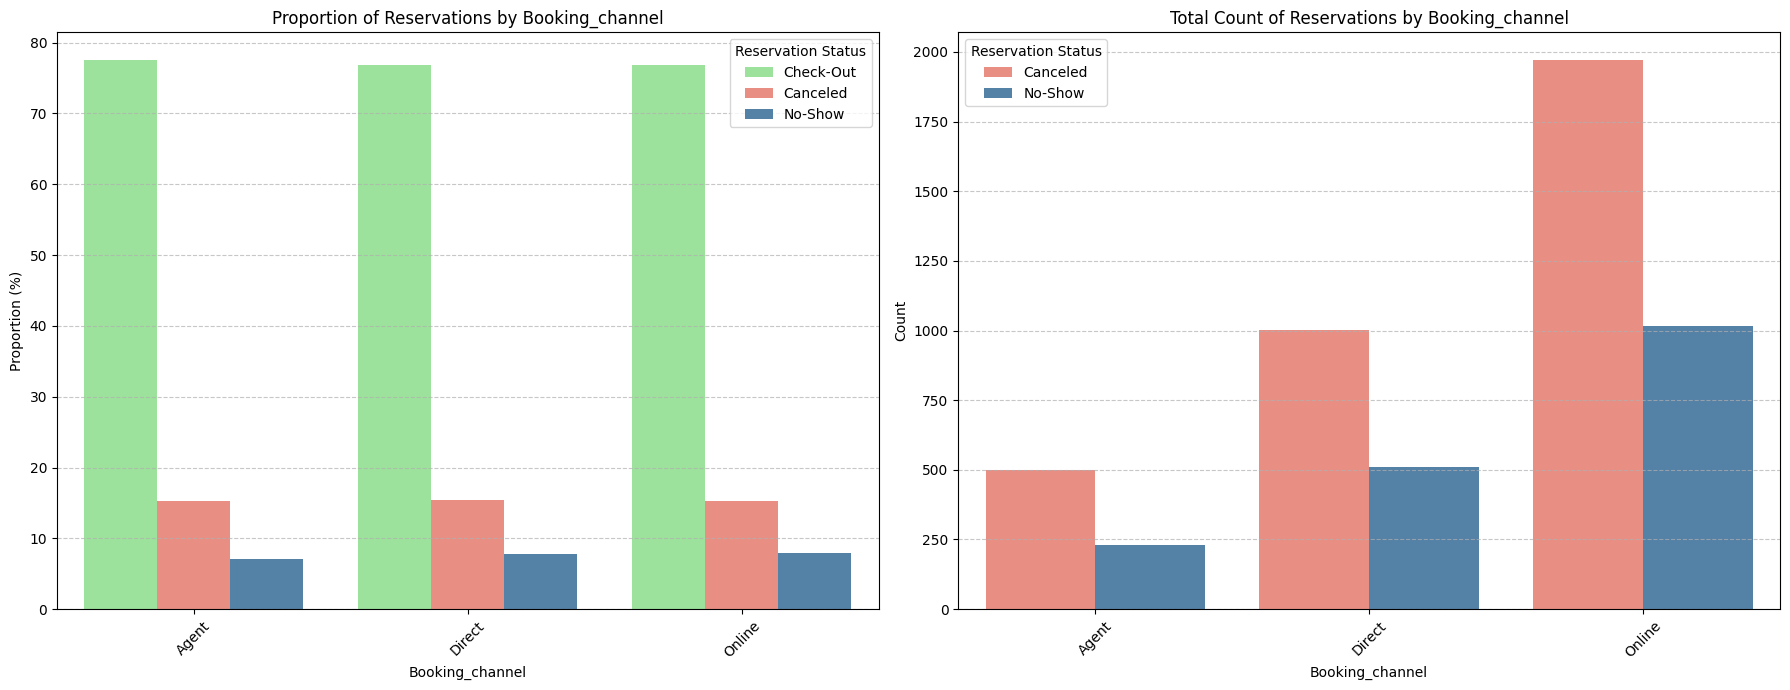

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare Proportion Data (as per your original logic)
status_education_proportions = (
    main_df.groupby('Booking_channel')['Reservation_Status_Encoded']
    .value_counts(normalize=True)
    .mul(100)
    .rename('Proportion_Percentage')
    .reset_index()
)

# 2. Create the figure with 2 subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- PLOT 1: PROPORTIONS (Left) ---
sns.barplot(data=status_education_proportions,
            x='Booking_channel',
            y='Proportion_Percentage',
            hue='Reservation_Status_Encoded',
            palette={1: 'lightgreen', 2: 'salmon', 3: 'steelblue'}, # Added color for status 1
            ax=axes[0])

axes[0].set_title('Proportion of Reservations by Booking_channel')
axes[0].set_ylabel('Proportion (%)')
axes[0].tick_params(axis='x', rotation=45)

# --- PLOT 2: RAW COUNTS (Right) ---
sns.countplot(data=canceled_no_show_df,
              x='Booking_channel',
              hue='Reservation_Status_Encoded',
              palette={2: 'salmon', 3: 'steelblue'},
              ax=axes[1])

axes[1].set_title('Total Count of Reservations by Booking_channel')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

# 3. Uniform Legend Handling for both plots
# Updated new_labels_map to include status 1 for the first plot's legend if it were to be handled by this loop
new_labels_map = {1: 'Check-Out', 2: 'Canceled', 3: 'No-Show'}

for ax in axes:
    handles, labels = ax.get_legend_handles_labels()
    # Map the labels based on the dictionary
    mapped_labels = [new_labels_map[int(float(label))] for label in labels]
    ax.legend(handles, mapped_labels, title='Reservation Status')
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Previous cancellations Vs reservations

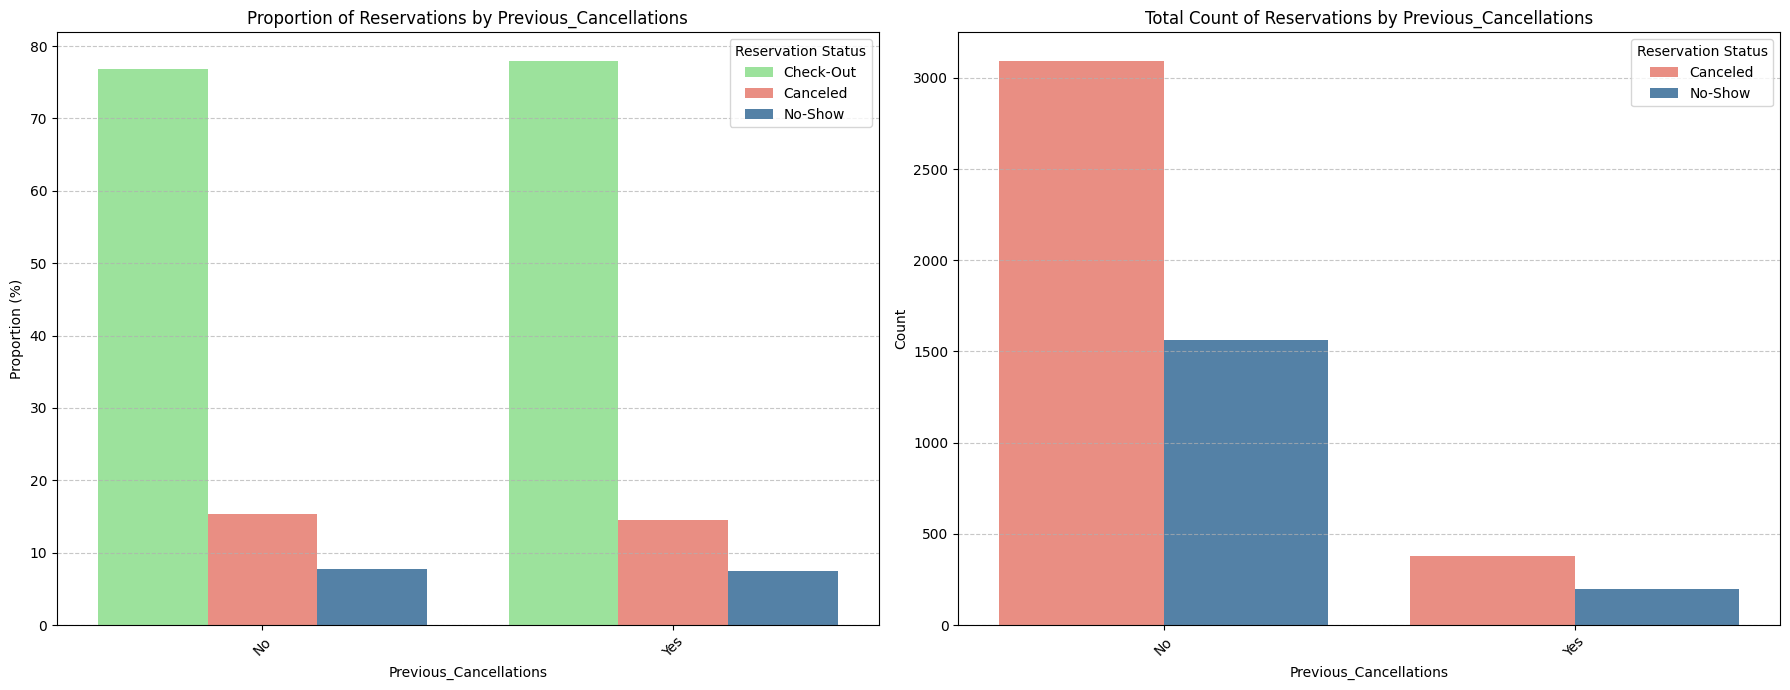

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare Proportion Data (as per your original logic)
status_education_proportions = (
    main_df.groupby('Previous_Cancellations')['Reservation_Status_Encoded']
    .value_counts(normalize=True)
    .mul(100)
    .rename('Proportion_Percentage')
    .reset_index()
)

# 2. Create the figure with 2 subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- PLOT 1: PROPORTIONS (Left) ---
sns.barplot(data=status_education_proportions,
            x='Previous_Cancellations',
            y='Proportion_Percentage',
            hue='Reservation_Status_Encoded',
            palette={1: 'lightgreen', 2: 'salmon', 3: 'steelblue'}, # Added color for status 1
            ax=axes[0])

axes[0].set_title('Proportion of Reservations by Previous_Cancellations')
axes[0].set_ylabel('Proportion (%)')
axes[0].tick_params(axis='x', rotation=45)

# --- PLOT 2: RAW COUNTS (Right) ---
sns.countplot(data=canceled_no_show_df,
              x='Previous_Cancellations',
              hue='Reservation_Status_Encoded',
              palette={2: 'salmon', 3: 'steelblue'},
              ax=axes[1])

axes[1].set_title('Total Count of Reservations by Previous_Cancellations')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

# 3. Uniform Legend Handling for both plots
# Updated new_labels_map to include status 1 for the first plot's legend if it were to be handled by this loop
new_labels_map = {1: 'Check-Out', 2: 'Canceled', 3: 'No-Show'}

for ax in axes:
    handles, labels = ax.get_legend_handles_labels()
    # Map the labels based on the dictionary
    mapped_labels = [new_labels_map[int(float(label))] for label in labels]
    ax.legend(handles, mapped_labels, title='Reservation Status')
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Trend: Reservation Status (Canceled/No-Show) vs. Weekend Check-in

This visualization will show the proportion of 'Canceled' (2) and 'No-Show' (3) reservations based on whether the check-in (`Is_Weekend`) is on a weekend or not, using the `canceled_no_show_df`.

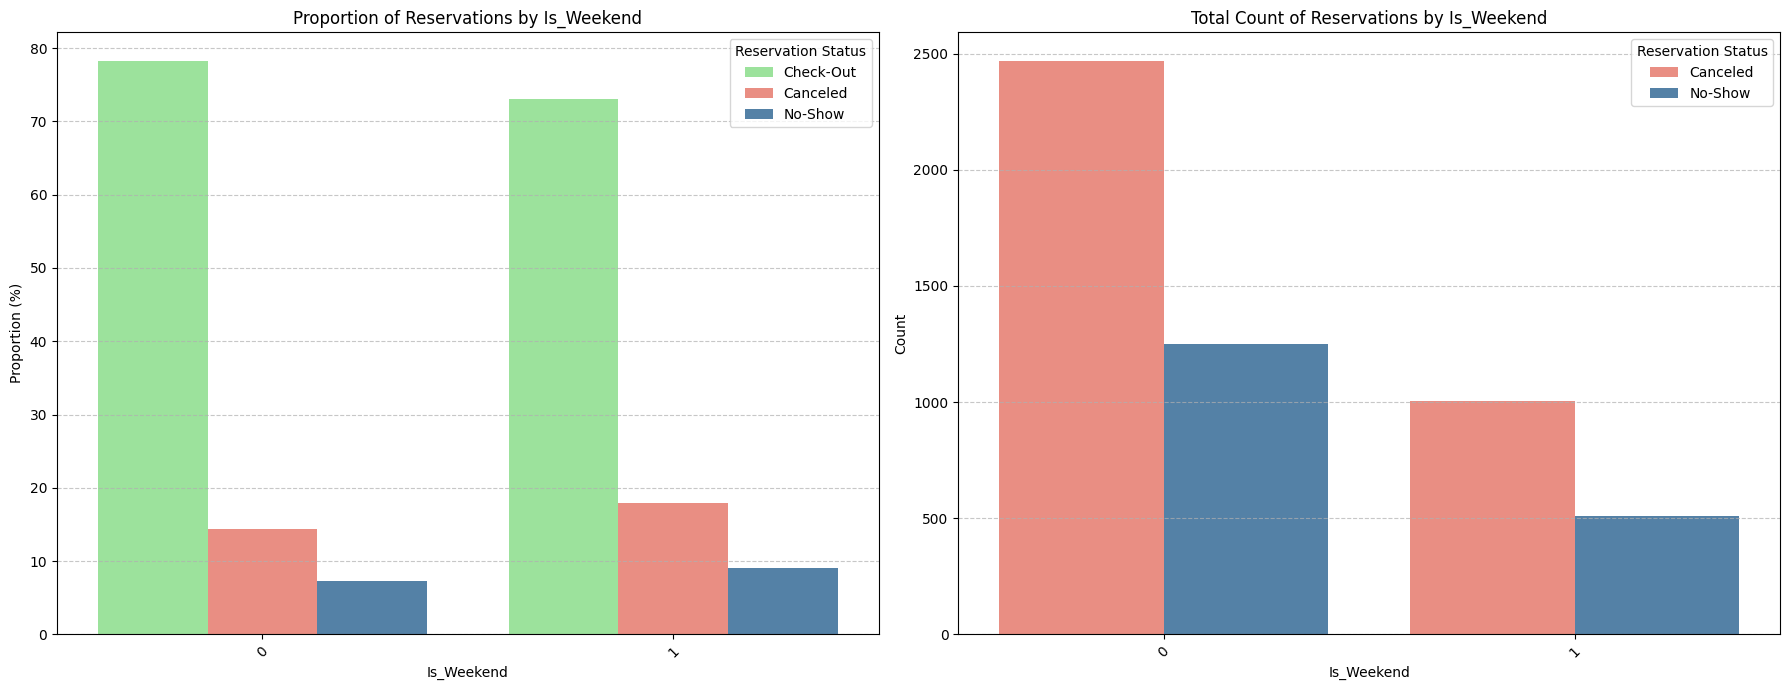

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare Proportion Data (as per your original logic)
status_education_proportions = (
    main_df.groupby('Is_Weekend')['Reservation_Status_Encoded']
    .value_counts(normalize=True)
    .mul(100)
    .rename('Proportion_Percentage')
    .reset_index()
)

# 2. Create the figure with 2 subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- PLOT 1: PROPORTIONS (Left) ---
sns.barplot(data=status_education_proportions,
            x='Is_Weekend',
            y='Proportion_Percentage',
            hue='Reservation_Status_Encoded',
            palette={1: 'lightgreen', 2: 'salmon', 3: 'steelblue'}, # Added color for status 1
            ax=axes[0])

axes[0].set_title('Proportion of Reservations by Is_Weekend')
axes[0].set_ylabel('Proportion (%)')
axes[0].tick_params(axis='x', rotation=45)

# --- PLOT 2: RAW COUNTS (Right) ---
sns.countplot(data=canceled_no_show_df,
              x='Is_Weekend',
              hue='Reservation_Status_Encoded',
              palette={2: 'salmon', 3: 'steelblue'},
              ax=axes[1])

axes[1].set_title('Total Count of Reservations by Is_Weekend')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

# 3. Uniform Legend Handling for both plots
# Updated new_labels_map to include status 1 for the first plot's legend if it were to be handled by this loop
new_labels_map = {1: 'Check-Out', 2: 'Canceled', 3: 'No-Show'}

for ax in axes:
    handles, labels = ax.get_legend_handles_labels()
    # Map the labels based on the dictionary
    mapped_labels = [new_labels_map[int(float(label))] for label in labels]
    ax.legend(handles, mapped_labels, title='Reservation Status')
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Trend: Reservation Status (Canceled/No-Show) vs. Check-in Month (Seasonality)

This visualization will show the proportion of 'Canceled' (2) and 'No-Show' (3) reservations across different `Checkin_Month` categories using the `canceled_no_show_df`.

# CHECK- IN MONTH VS RESERVATIONS

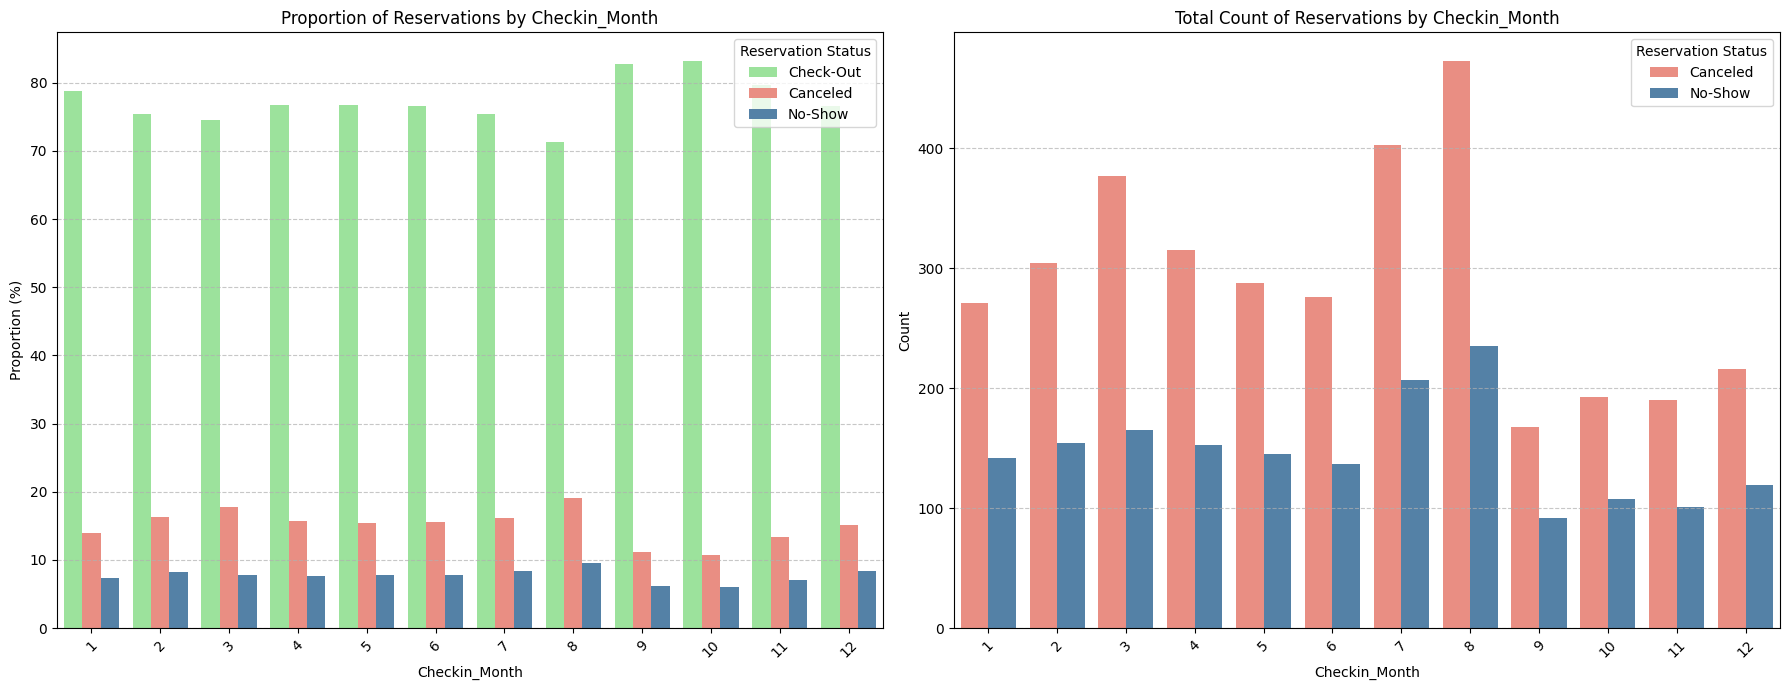

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare Proportion Data (as per your original logic)
status_education_proportions = (
    main_df.groupby('Checkin_Month')['Reservation_Status_Encoded']
    .value_counts(normalize=True)
    .mul(100)
    .rename('Proportion_Percentage')
    .reset_index()
)

# 2. Create the figure with 2 subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- PLOT 1: PROPORTIONS (Left) ---
sns.barplot(data=status_education_proportions,
            x='Checkin_Month',
            y='Proportion_Percentage',
            hue='Reservation_Status_Encoded',
            palette={1: 'lightgreen', 2: 'salmon', 3: 'steelblue'}, # Added color for status 1
            ax=axes[0])

axes[0].set_title('Proportion of Reservations by Checkin_Month')
axes[0].set_ylabel('Proportion (%)')
axes[0].tick_params(axis='x', rotation=45)

# --- PLOT 2: RAW COUNTS (Right) ---
sns.countplot(data=canceled_no_show_df,
              x='Checkin_Month',
              hue='Reservation_Status_Encoded',
              palette={2: 'salmon', 3: 'steelblue'},
              ax=axes[1])

axes[1].set_title('Total Count of Reservations by Checkin_Month')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

# 3. Uniform Legend Handling for both plots
# Updated new_labels_map to include status 1 for the first plot's legend if it were to be handled by this loop
new_labels_map = {1: 'Check-Out', 2: 'Canceled', 3: 'No-Show'}

for ax in axes:
    handles, labels = ax.get_legend_handles_labels()
    # Map the labels based on the dictionary
    mapped_labels = [new_labels_map[int(float(label))] for label in labels]
    ax.legend(handles, mapped_labels, title='Reservation Status')
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Car Parking Categroy

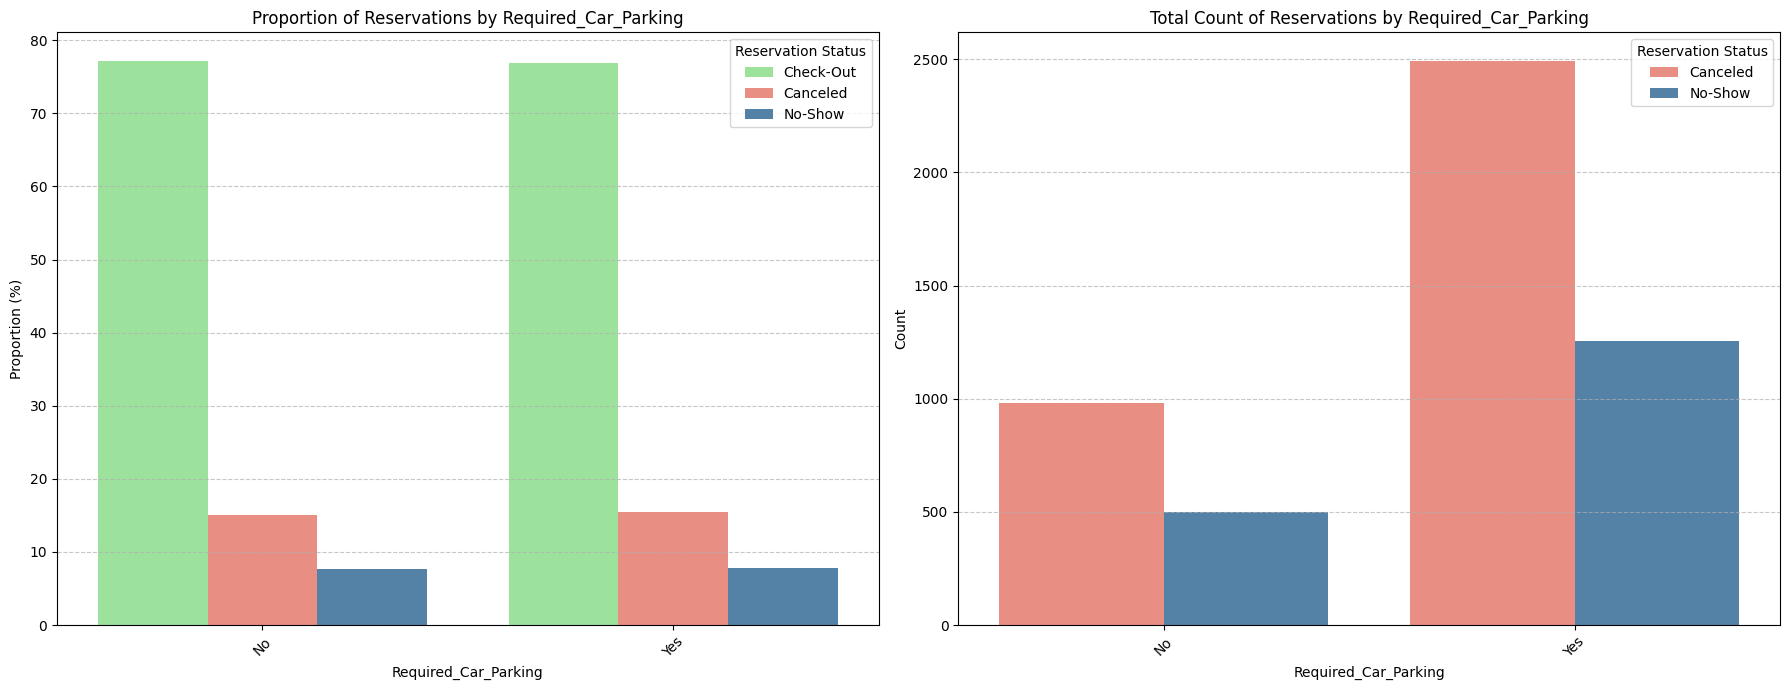

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare Proportion Data (as per your original logic)
status_education_proportions = (
    main_df.groupby('Required_Car_Parking')['Reservation_Status_Encoded']
    .value_counts(normalize=True)
    .mul(100)
    .rename('Proportion_Percentage')
    .reset_index()
)

# 2. Create the figure with 2 subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- PLOT 1: PROPORTIONS (Left) ---
sns.barplot(data=status_education_proportions,
            x='Required_Car_Parking',
            y='Proportion_Percentage',
            hue='Reservation_Status_Encoded',
            palette={1: 'lightgreen', 2: 'salmon', 3: 'steelblue'}, # Added color for status 1
            ax=axes[0])

axes[0].set_title('Proportion of Reservations by Required_Car_Parking')
axes[0].set_ylabel('Proportion (%)')
axes[0].tick_params(axis='x', rotation=45)

# --- PLOT 2: RAW COUNTS (Right) ---
sns.countplot(data=canceled_no_show_df,
              x='Required_Car_Parking',
              hue='Reservation_Status_Encoded',
              palette={2: 'salmon', 3: 'steelblue'},
              ax=axes[1])

axes[1].set_title('Total Count of Reservations by Required_Car_Parking')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

# 3. Uniform Legend Handling for both plots
# Updated new_labels_map to include status 1 for the first plot's legend if it were to be handled by this loop
new_labels_map = {1: 'Check-Out', 2: 'Canceled', 3: 'No-Show'}

for ax in axes:
    handles, labels = ax.get_legend_handles_labels()
    # Map the labels based on the dictionary
    mapped_labels = [new_labels_map[int(float(label))] for label in labels]
    ax.legend(handles, mapped_labels, title='Reservation Status')
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# GENDER


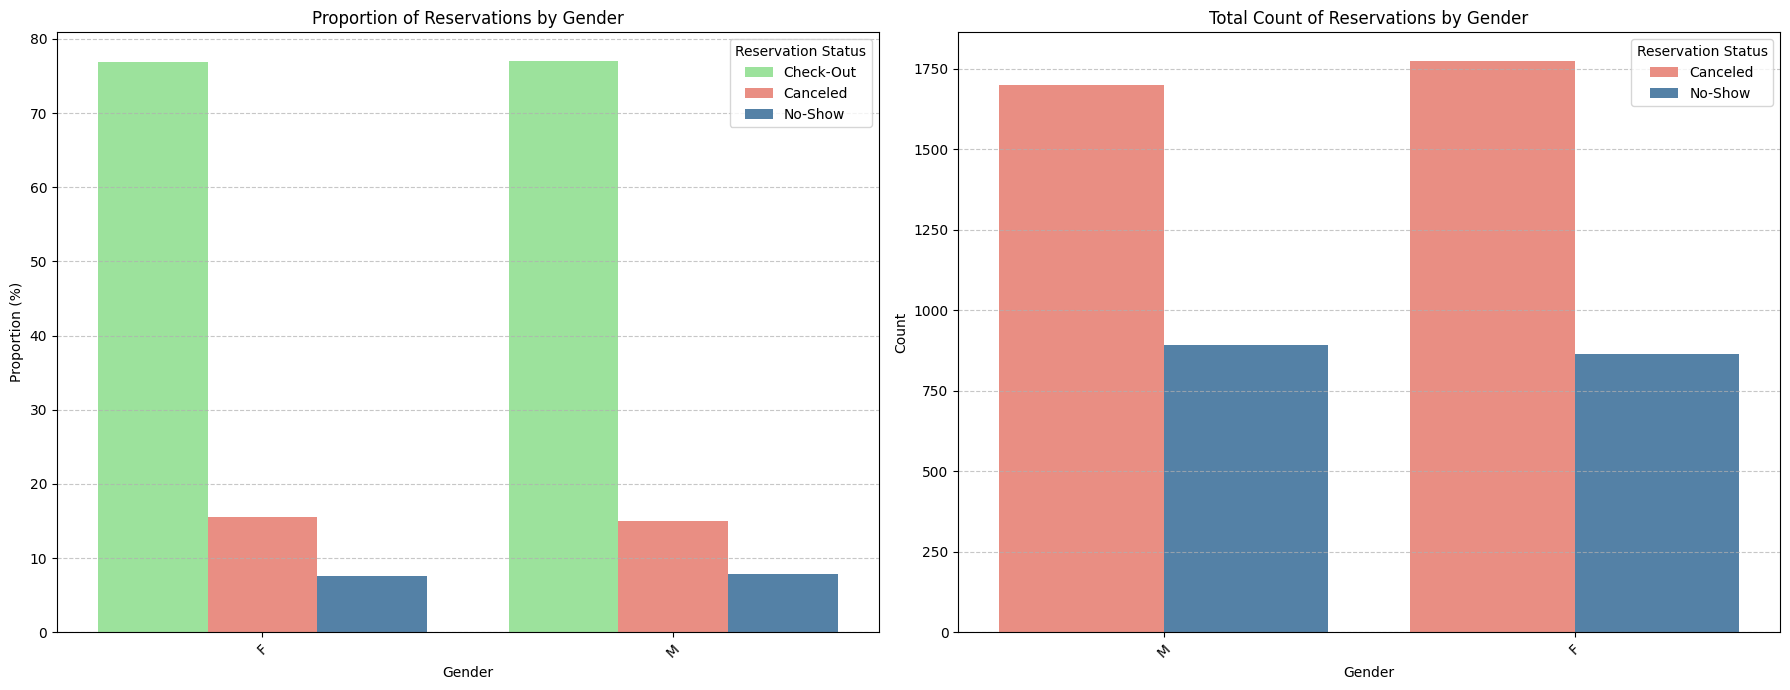

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare Proportion Data (as per your original logic)
status_education_proportions = (
    main_df.groupby('Gender')['Reservation_Status_Encoded']
    .value_counts(normalize=True)
    .mul(100)
    .rename('Proportion_Percentage')
    .reset_index()
)

# 2. Create the figure with 2 subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- PLOT 1: PROPORTIONS (Left) ---
sns.barplot(data=status_education_proportions,
            x='Gender',
            y='Proportion_Percentage',
            hue='Reservation_Status_Encoded',
            palette={1: 'lightgreen', 2: 'salmon', 3: 'steelblue'}, # Added color for status 1
            ax=axes[0])

axes[0].set_title('Proportion of Reservations by Gender')
axes[0].set_ylabel('Proportion (%)')
axes[0].tick_params(axis='x', rotation=45)

# --- PLOT 2: RAW COUNTS (Right) ---
sns.countplot(data=canceled_no_show_df,
              x='Gender',
              hue='Reservation_Status_Encoded',
              palette={2: 'salmon', 3: 'steelblue'},
              ax=axes[1])

axes[1].set_title('Total Count of Reservations by Gender')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

# 3. Uniform Legend Handling for both plots
# Updated new_labels_map to include status 1 for the first plot's legend if it were to be handled by this loop
new_labels_map = {1: 'Check-Out', 2: 'Canceled', 3: 'No-Show'}

for ax in axes:
    handles, labels = ax.get_legend_handles_labels()
    # Map the labels based on the dictionary
    mapped_labels = [new_labels_map[int(float(label))] for label in labels]
    ax.legend(handles, mapped_labels, title='Reservation Status')
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Ethinicity

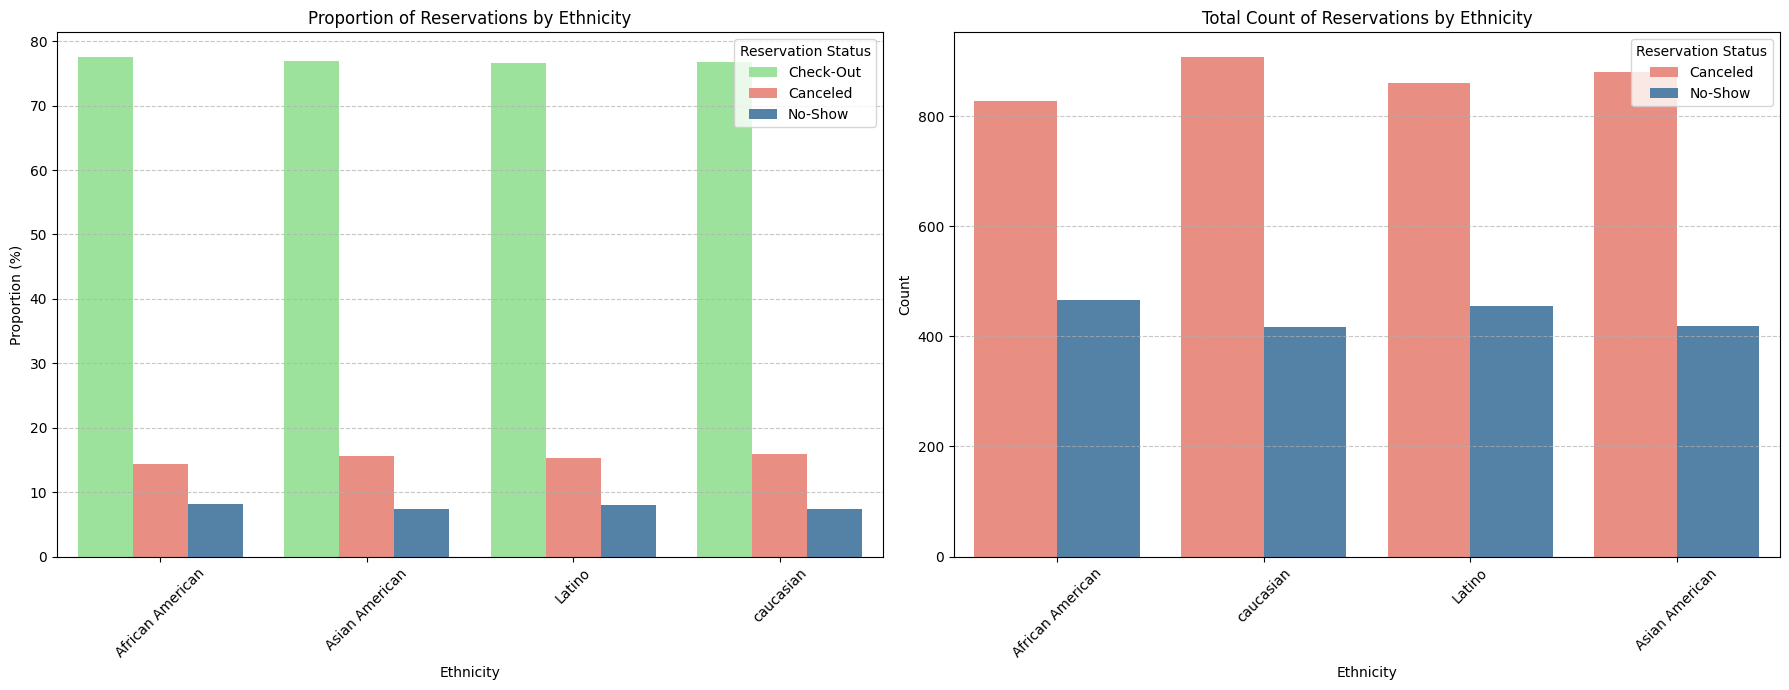

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare Proportion Data (as per your original logic)
status_education_proportions = (
    main_df.groupby('Ethnicity')['Reservation_Status_Encoded']
    .value_counts(normalize=True)
    .mul(100)
    .rename('Proportion_Percentage')
    .reset_index()
)

# 2. Create the figure with 2 subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- PLOT 1: PROPORTIONS (Left) ---
sns.barplot(data=status_education_proportions,
            x='Ethnicity',
            y='Proportion_Percentage',
            hue='Reservation_Status_Encoded',
            palette={1: 'lightgreen', 2: 'salmon', 3: 'steelblue'}, # Added color for status 1
            ax=axes[0])

axes[0].set_title('Proportion of Reservations by Ethnicity')
axes[0].set_ylabel('Proportion (%)')
axes[0].tick_params(axis='x', rotation=45)

# --- PLOT 2: RAW COUNTS (Right) ---
sns.countplot(data=canceled_no_show_df,
              x='Ethnicity',
              hue='Reservation_Status_Encoded',
              palette={2: 'salmon', 3: 'steelblue'},
              ax=axes[1])

axes[1].set_title('Total Count of Reservations by Ethnicity')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

# 3. Uniform Legend Handling for both plots
# Updated new_labels_map to include status 1 for the first plot's legend if it were to be handled by this loop
new_labels_map = {1: 'Check-Out', 2: 'Canceled', 3: 'No-Show'}

for ax in axes:
    handles, labels = ax.get_legend_handles_labels()
    # Map the labels based on the dictionary
    mapped_labels = [new_labels_map[int(float(label))] for label in labels]
    ax.legend(handles, mapped_labels, title='Reservation Status')
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Country Region

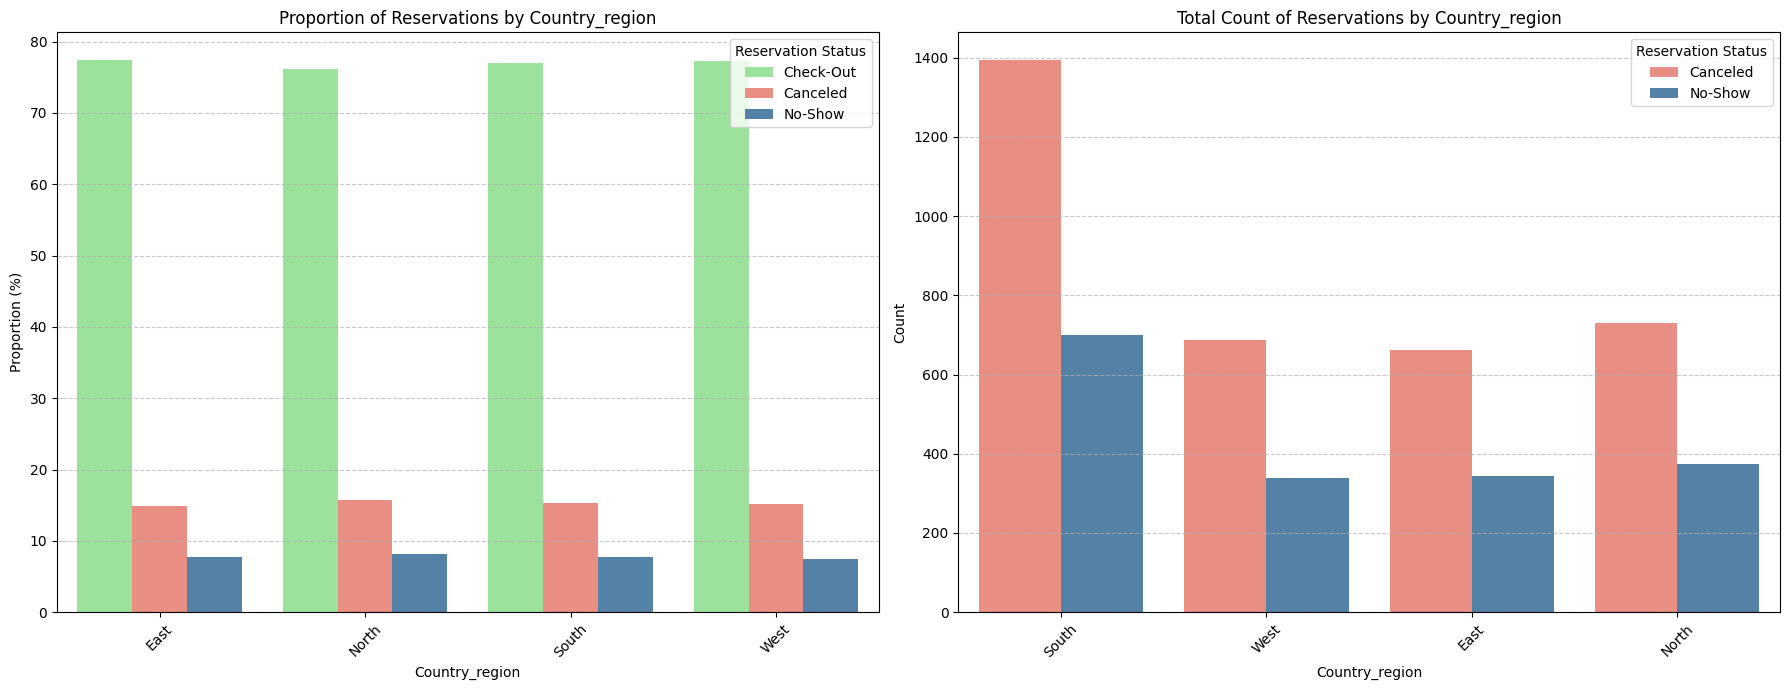

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare Proportion Data (as per your original logic)
status_education_proportions = (
    main_df.groupby('Country_region')['Reservation_Status_Encoded']
    .value_counts(normalize=True)
    .mul(100)
    .rename('Proportion_Percentage')
    .reset_index()
)

# 2. Create the figure with 2 subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- PLOT 1: PROPORTIONS (Left) ---
sns.barplot(data=status_education_proportions,
            x='Country_region',
            y='Proportion_Percentage',
            hue='Reservation_Status_Encoded',
            palette={1: 'lightgreen', 2: 'salmon', 3: 'steelblue'}, # Added color for status 1
            ax=axes[0])

axes[0].set_title('Proportion of Reservations by Country_region')
axes[0].set_ylabel('Proportion (%)')
axes[0].tick_params(axis='x', rotation=45)

# --- PLOT 2: RAW COUNTS (Right) ---
sns.countplot(data=canceled_no_show_df,
              x='Country_region',
              hue='Reservation_Status_Encoded',
              palette={2: 'salmon', 3: 'steelblue'},
              ax=axes[1])

axes[1].set_title('Total Count of Reservations by Country_region')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

# 3. Uniform Legend Handling for both plots
# Updated new_labels_map to include status 1 for the first plot's legend if it were to be handled by this loop
new_labels_map = {1: 'Check-Out', 2: 'Canceled', 3: 'No-Show'}

for ax in axes:
    handles, labels = ax.get_legend_handles_labels()
    # Map the labels based on the dictionary
    mapped_labels = [new_labels_map[int(float(label))] for label in labels]
    ax.legend(handles, mapped_labels, title='Reservation Status')
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Hotel Type

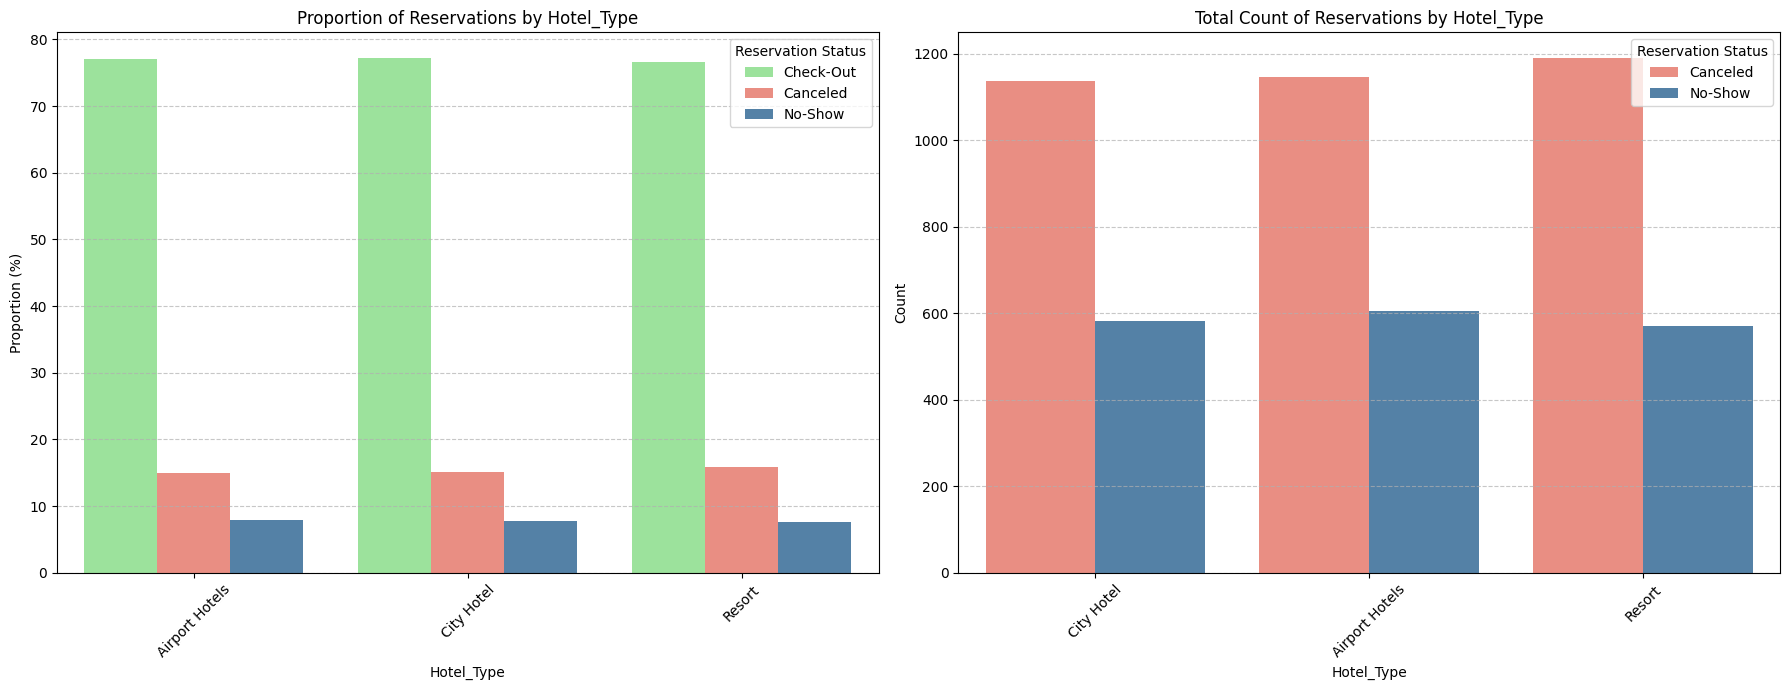

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare Proportion Data (as per your original logic)
status_education_proportions = (
    main_df.groupby('Hotel_Type')['Reservation_Status_Encoded']
    .value_counts(normalize=True)
    .mul(100)
    .rename('Proportion_Percentage')
    .reset_index()
)

# 2. Create the figure with 2 subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- PLOT 1: PROPORTIONS (Left) ---
sns.barplot(data=status_education_proportions,
            x='Hotel_Type',
            y='Proportion_Percentage',
            hue='Reservation_Status_Encoded',
            palette={1: 'lightgreen', 2: 'salmon', 3: 'steelblue'}, # Added color for status 1
            ax=axes[0])

axes[0].set_title('Proportion of Reservations by Hotel_Type')
axes[0].set_ylabel('Proportion (%)')
axes[0].tick_params(axis='x', rotation=45)

# --- PLOT 2: RAW COUNTS (Right) ---
sns.countplot(data=canceled_no_show_df,
              x='Hotel_Type',
              hue='Reservation_Status_Encoded',
              palette={2: 'salmon', 3: 'steelblue'},
              ax=axes[1])

axes[1].set_title('Total Count of Reservations by Hotel_Type')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

# 3. Uniform Legend Handling for both plots
# Updated new_labels_map to include status 1 for the first plot's legend if it were to be handled by this loop
new_labels_map = {1: 'Check-Out', 2: 'Canceled', 3: 'No-Show'}

for ax in axes:
    handles, labels = ax.get_legend_handles_labels()
    # Map the labels based on the dictionary
    mapped_labels = [new_labels_map[int(float(label))] for label in labels]
    ax.legend(handles, mapped_labels, title='Reservation Status')
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# MEal Type

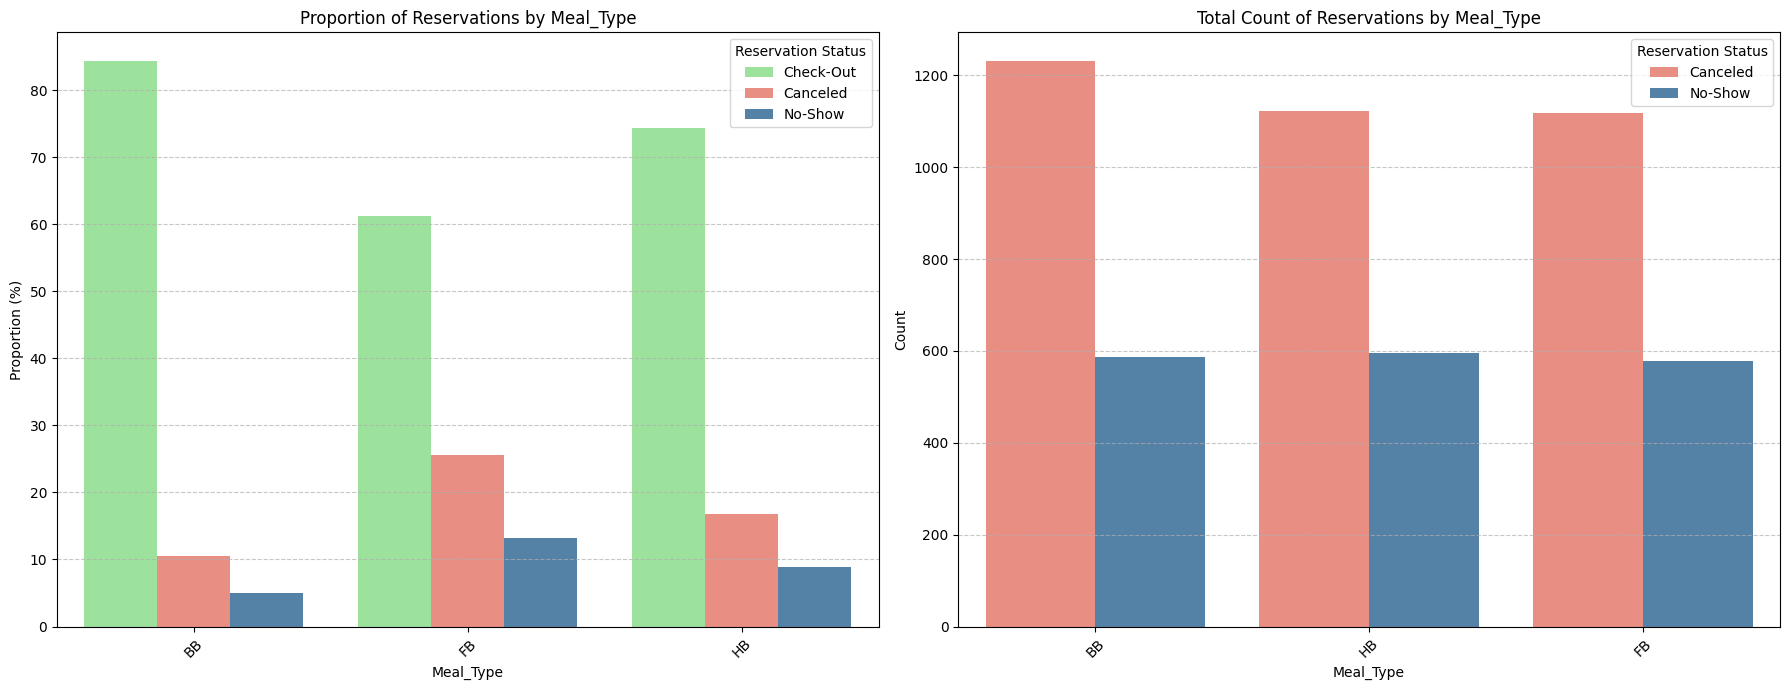

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare Proportion Data (as per your original logic)
status_education_proportions = (
    main_df.groupby('Meal_Type')['Reservation_Status_Encoded']
    .value_counts(normalize=True)
    .mul(100)
    .rename('Proportion_Percentage')
    .reset_index()
)

# 2. Create the figure with 2 subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- PLOT 1: PROPORTIONS (Left) ---
sns.barplot(data=status_education_proportions,
            x='Meal_Type',
            y='Proportion_Percentage',
            hue='Reservation_Status_Encoded',
            palette={1: 'lightgreen', 2: 'salmon', 3: 'steelblue'}, # Added color for status 1
            ax=axes[0])

axes[0].set_title('Proportion of Reservations by Meal_Type')
axes[0].set_ylabel('Proportion (%)')
axes[0].tick_params(axis='x', rotation=45)

# --- PLOT 2: RAW COUNTS (Right) ---
sns.countplot(data=canceled_no_show_df,
              x='Meal_Type',
              hue='Reservation_Status_Encoded',
              palette={2: 'salmon', 3: 'steelblue'},
              ax=axes[1])

axes[1].set_title('Total Count of Reservations by Meal_Type')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

# 3. Uniform Legend Handling for both plots
# Updated new_labels_map to include status 1 for the first plot's legend if it were to be handled by this loop
new_labels_map = {1: 'Check-Out', 2: 'Canceled', 3: 'No-Show'}

for ax in axes:
    handles, labels = ax.get_legend_handles_labels()
    # Map the labels based on the dictionary
    mapped_labels = [new_labels_map[int(float(label))] for label in labels]
    ax.legend(handles, mapped_labels, title='Reservation Status')
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Use Promotion

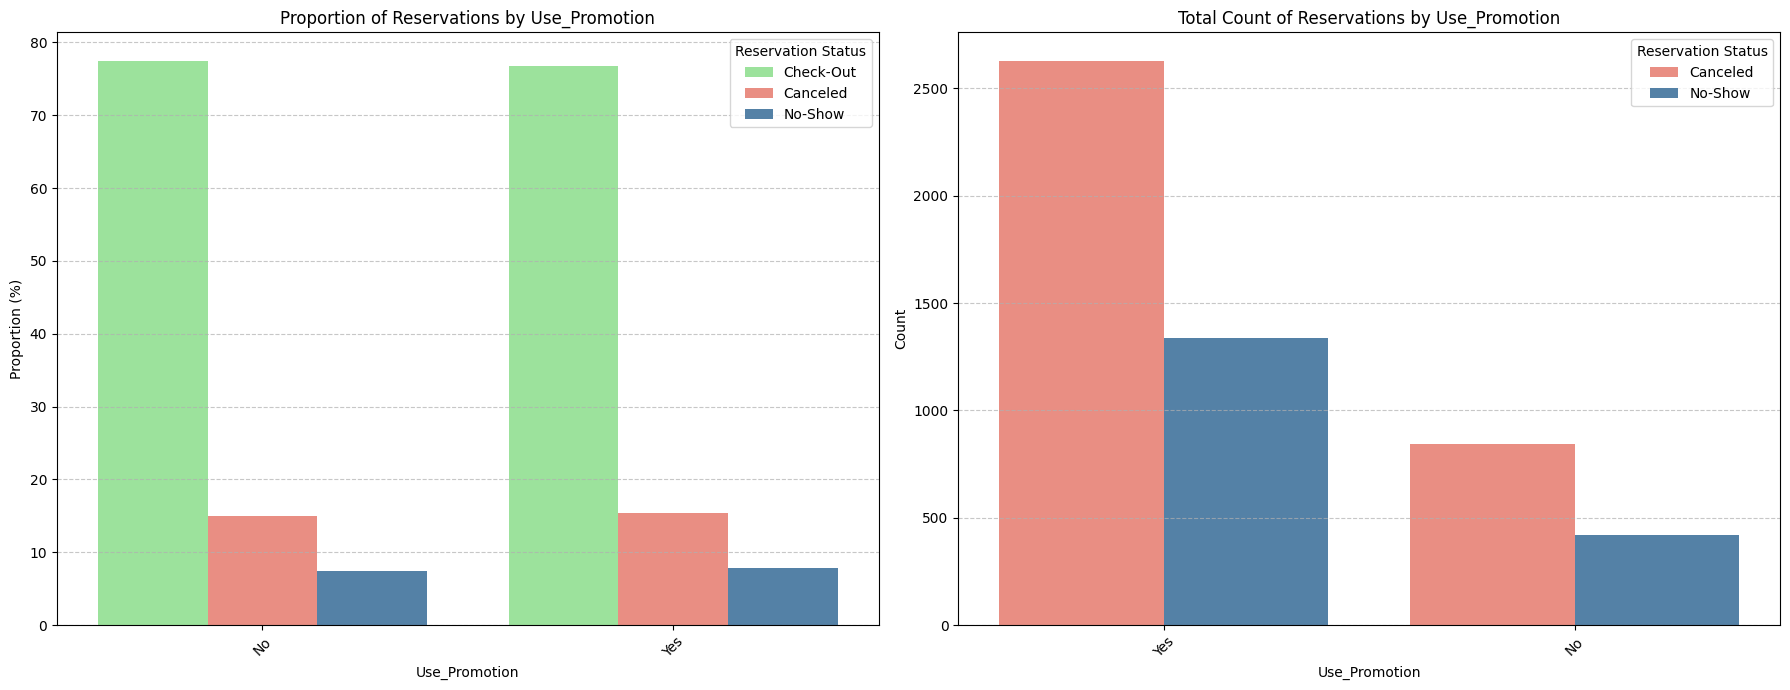

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare Proportion Data (as per your original logic)
status_education_proportions = (
    main_df.groupby('Use_Promotion')['Reservation_Status_Encoded']
    .value_counts(normalize=True)
    .mul(100)
    .rename('Proportion_Percentage')
    .reset_index()
)

# 2. Create the figure with 2 subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- PLOT 1: PROPORTIONS (Left) ---
sns.barplot(data=status_education_proportions,
            x='Use_Promotion',
            y='Proportion_Percentage',
            hue='Reservation_Status_Encoded',
            palette={1: 'lightgreen', 2: 'salmon', 3: 'steelblue'}, # Added color for status 1
            ax=axes[0])

axes[0].set_title('Proportion of Reservations by Use_Promotion')
axes[0].set_ylabel('Proportion (%)')
axes[0].tick_params(axis='x', rotation=45)

# --- PLOT 2: RAW COUNTS (Right) ---
sns.countplot(data=canceled_no_show_df,
              x='Use_Promotion',
              hue='Reservation_Status_Encoded',
              palette={2: 'salmon', 3: 'steelblue'},
              ax=axes[1])

axes[1].set_title('Total Count of Reservations by Use_Promotion')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

# 3. Uniform Legend Handling for both plots
# Updated new_labels_map to include status 1 for the first plot's legend if it were to be handled by this loop
new_labels_map = {1: 'Check-Out', 2: 'Canceled', 3: 'No-Show'}

for ax in axes:
    handles, labels = ax.get_legend_handles_labels()
    # Map the labels based on the dictionary
    mapped_labels = [new_labels_map[int(float(label))] for label in labels]
    ax.legend(handles, mapped_labels, title='Reservation Status')
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# REVENUE LOSS ANALYSIS

## Calculate Potential Revenue

### Subtask:
Create a new column 'Potential_Revenue' in `main_df` by multiplying `Room_Rate` by `Total Nights` for each reservation. This represents the revenue generated if the booking were completed.


**Reasoning**:
To create the 'Potential_Revenue' column, I need to multiply the 'Room_Rate' and 'Total Nights' columns from the `main_df` and then display the head of the dataframe to verify the new column.



In [ ]:
main_df['Potential_Revenue'] = main_df['Room_Rate'] * main_df['Total Nights']

main_df.head()

,Reservation-id,Gender,Age,Ethnicity,Educational_Level,Income,Country_region,Hotel_Type,Expected_checkin,Expected_checkout,...,Discount_Rate,Room_Rate,Lead_Time,Total Nights,Checkin_Month,Checkin_Day_of_Week,Is_Weekend,Total_Guests,Reservation_Status_Encoded,Potential_Revenue
0,39428300,F,40,Latino,Grad,<25K,North,City Hotel,2015-07-01,2015-07-02,...,10,218,41,1,7,2,0,4,1,218
1,77222321,F,62,Latino,High-School,25K --50K,East,Resort,2015-07-03,2015-07-04,...,10,242,13,1,7,4,0,2,1,242
2,7647912,M,40,Latino,Mid-School,>100K,North,City Hotel,2015-07-03,2015-07-04,...,0,170,8,1,7,4,0,3,1,170
3,94296865,M,59,African American,Mid-School,>100K,West,Resort,2015-05-06,2015-05-07,...,10,245,84,1,5,2,0,5,1,245
4,93087487,M,21,Latino,Grad,50K -- 100K,West,City Hotel,2015-04-22,2015-04-25,...,20,212,72,3,4,2,0,5,1,636


In [ ]:
revenue_by_status = main_df.groupby('Reservation_Status_Encoded')['Potential_Revenue'].sum()
print("Total Potential Revenue by Reservation Status:")
print(revenue_by_status)

Total Potential Revenue by Reservation Status:
Reservation_Status_Encoded
1    5580869
2    1108886
3     568516
Name: Potential_Revenue, dtype: int64


In [ ]:
main_df_toPcsv = main_df.to_csv('main_df.csv', index=False)

In [ ]:
total_potential_revenue = main_df['Potential_Revenue'].sum()

# Total revenue lost (Canceled + No-Show)
total_lost_revenue = revenue_by_status.loc[2] + revenue_by_status.loc[3]

# Total revenue earned (Check-Out)
total_earned_revenue = revenue_by_status.loc[1]

# Calculate percentage revenue lost
percentage_revenue_lost = (total_lost_revenue / total_potential_revenue) * 100

# Calculate percentage revenue earned
percentage_revenue_earned = (total_earned_revenue / total_potential_revenue) * 100

print(f"Total Potential Revenue: ${total_potential_revenue:,.2f}")
print(f"Total Revenue Lost (Canceled + No-Show): ${total_lost_revenue:,.2f}")
print(f"Percentage Revenue Lost: {percentage_revenue_lost:.2f}%")
print(f"Total Revenue Earned (Check-Out): ${total_earned_revenue:,.2f}")
print(f"Percentage Revenue Earned: {percentage_revenue_earned:.2f}%")

Total Potential Revenue: $7,258,271.00
Total Revenue Lost (Canceled + No-Show): $1,677,402.00
Percentage Revenue Lost: 23.11%
Total Revenue Earned (Check-Out): $5,580,869.00
Percentage Revenue Earned: 76.89%


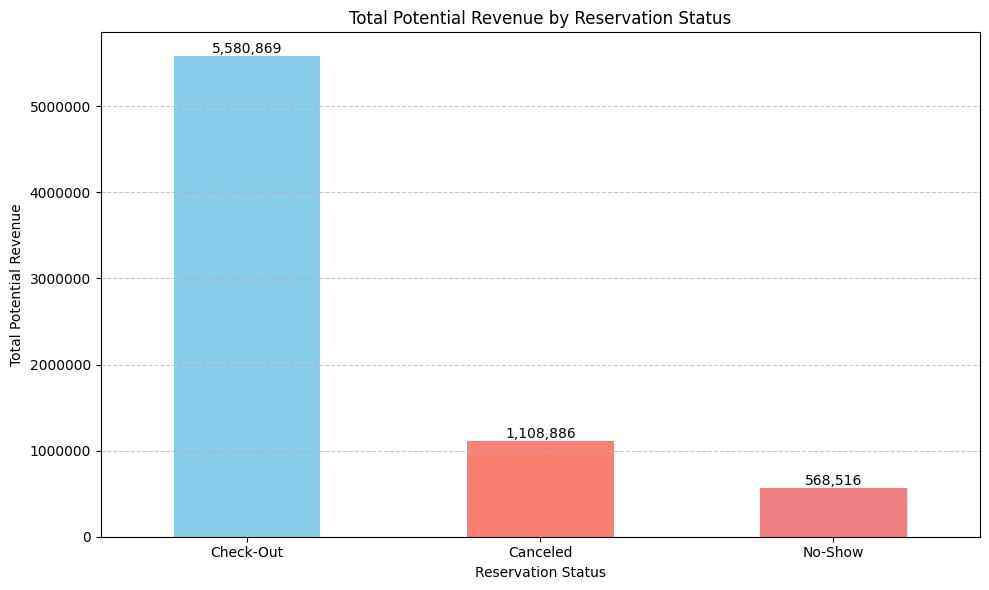

In [ ]:
plt.figure(figsize=(10, 6))
ax = revenue_by_status.plot(kind='bar', color=['skyblue', 'salmon', 'lightcoral'])

# Define the status_labels dictionary
status_labels = {
    1: 'Check-Out',
    2: 'Canceled',
    3: 'No-Show'
}

# Use the length of the series to set the tick positions (0, 1, 2...)
plt.xticks(
    ticks=range(len(revenue_by_status)),
    labels=[status_labels.get(x, x) for x in revenue_by_status.index],
    rotation=0
)

# Add data labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}')

plt.title('Total Potential Revenue by Reservation Status')
plt.xlabel('Reservation Status')
plt.ylabel('Total Potential Revenue')
plt.ticklabel_format(style='plain', axis='y')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Reasoning**:
First, I'll calculate the minimum and maximum ages from the 'Age' column in the `canceled_no_show_df` to determine the appropriate range for creating age bins.



In [ ]:
min_age = canceled_no_show_df['Age'].min()
max_age = canceled_no_show_df['Age'].max()

print(f"Minimum Age: {min_age}")
print(f"Maximum Age: {max_age}")

Minimum Age: 18
Maximum Age: 70


**Reasoning**:
Now that the minimum and maximum ages have been determined, I will create age bins and labels using 10-year intervals and then apply these to the 'Age' column in the `canceled_no_show_df` to create a new 'Age_Bracket' column, as requested by the subtask instructions.



In [ ]:
bins = [18, 30, 40, 50, 60, 70, canceled_no_show_df['Age'].max() + 1] # Ensure the max age is included
labels = ['18-29', '30-39', '40-49', '50-59', '60-69', '70+']

# Create a copy to avoid SettingWithCopyWarning
canceled_no_show_df = canceled_no_show_df.copy()
canceled_no_show_df['Age_Bracket'] = pd.cut(canceled_no_show_df['Age'], bins=bins, labels=labels, right=False)

# Display the first few rows with the new 'Age_Bracket' column
display(canceled_no_show_df[['Age', 'Age_Bracket']].head())

# Print the value counts for the new 'Age_Bracket' column
print("Value counts for Age_Bracket:")
display(canceled_no_show_df['Age_Bracket'].value_counts().sort_index())

,Age,Age_Bracket
10413,44,40-49
10414,40,40-49
10421,41,40-49
10423,24,18-29
10425,28,18-29


Value counts for Age_Bracket:


,count
Age_Bracket,
18-29,1194
30-39,987
40-49,963
50-59,999
60-69,1005
70+,84


/tmp/ipykernel_3599/3919641272.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  lost_revenue_by_age = canceled_no_show_df.groupby(['Age_Bracket', 'Reservation_Status_Encoded'])['Potential_Revenue'].sum().unstack()


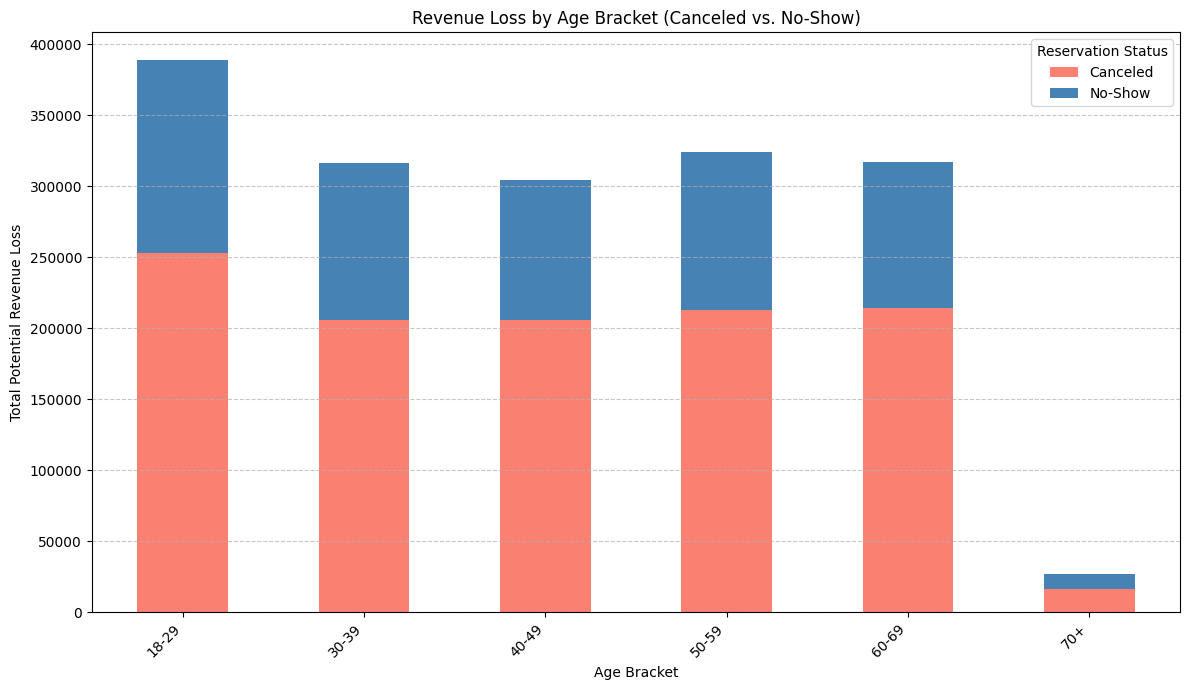

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Re-create canceled_no_show_df from main_df to ensure it has 'Potential_Revenue'
canceled_no_show_df = main_df[main_df['Reservation_Status_Encoded'].isin([2, 3])].copy()

# Define age bins and labels, ensuring max_age is correctly handled
min_age = canceled_no_show_df['Age'].min()
max_age = canceled_no_show_df['Age'].max()
bins = [18, 30, 40, 50, 60, 70, max_age + 1] # Ensure the max age is included
labels = ['18-29', '30-39', '40-49', '50-59', '60-69', '70+']

# Create 'Age_Bracket' column on the newly created canceled_no_show_df
canceled_no_show_df['Age_Bracket'] = pd.cut(canceled_no_show_df['Age'], bins=bins, labels=labels, right=False)

# Calculate the sum of 'Potential_Revenue' for 'Canceled' and 'No-Show' reservations within each 'Age_Bracket'
lost_revenue_by_age = canceled_no_show_df.groupby(['Age_Bracket', 'Reservation_Status_Encoded'])['Potential_Revenue'].sum().unstack()

# Rename columns for better readability in the plot
lost_revenue_by_age.rename(columns={2: 'Canceled', 3: 'No-Show'}, inplace=True)

# Generate a stacked bar chart
plt.figure(figsize=(12, 7))
lost_revenue_by_age.plot(kind='bar', stacked=True, color={'Canceled': 'salmon', 'No-Show': 'steelblue'}, ax=plt.gca())

plt.title('Revenue Loss by Age Bracket (Canceled vs. No-Show)')
plt.xlabel('Age Bracket')
plt.ylabel('Total Potential Revenue Loss')
plt.xticks(rotation=45, ha='right')
plt.ticklabel_format(style='plain', axis='y') # Ensure y-axis tick labels are not in scientific notation

# Create a custom legend
handles, labels_plot = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['Canceled', 'No-Show'], title='Reservation Status')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Reasoning**:
The next step is to visualize revenue loss by country/region. I will group the `canceled_no_show_df` by 'Country_region' and 'Reservation_Status_Encoded', sum the 'Potential_Revenue', and then create a stacked bar chart to show the lost revenue for 'Canceled' and 'No-Show' reservations per country/region.



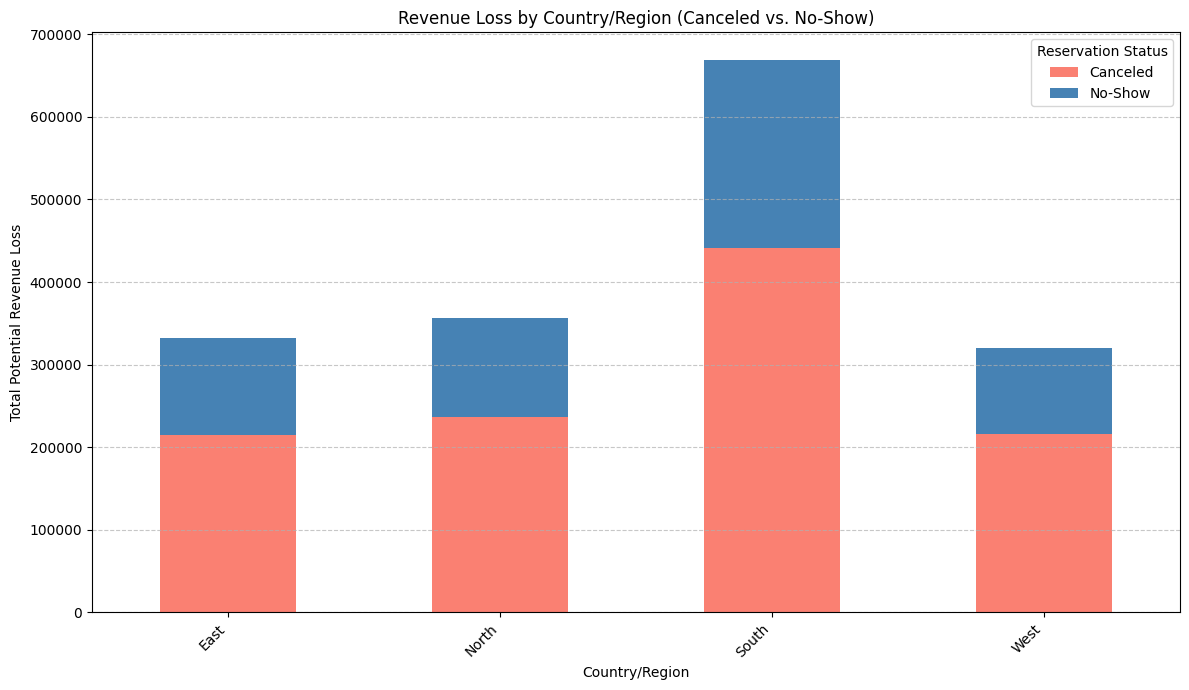

In [ ]:
# Calculate the sum of 'Potential_Revenue' for 'Canceled' and 'No-Show' reservations within each 'Country_region'
lost_revenue_by_country = canceled_no_show_df.groupby(['Country_region', 'Reservation_Status_Encoded'])['Potential_Revenue'].sum().unstack()

# Rename columns for better readability in the plot
lost_revenue_by_country.rename(columns={2: 'Canceled', 3: 'No-Show'}, inplace=True)

# Generate a stacked bar chart
plt.figure(figsize=(12, 7))
lost_revenue_by_country.plot(kind='bar', stacked=True, color={'Canceled': 'salmon', 'No-Show': 'steelblue'}, ax=plt.gca())

plt.title('Revenue Loss by Country/Region (Canceled vs. No-Show)')
plt.xlabel('Country/Region')
plt.ylabel('Total Potential Revenue Loss')
plt.xticks(rotation=45, ha='right')
plt.ticklabel_format(style='plain', axis='y') # Ensure y-axis tick labels are not in scientific notation

# Create a custom legend
handles, labels_plot = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['Canceled', 'No-Show'], title='Reservation Status')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Reasoning**:
The next step is to visualize revenue loss by hotel type. I will group the `canceled_no_show_df` by 'Hotel_Type' and 'Reservation_Status_Encoded', sum the 'Potential_Revenue', and then create a stacked bar chart to show the lost revenue for 'Canceled' and 'No-Show' reservations per hotel type.



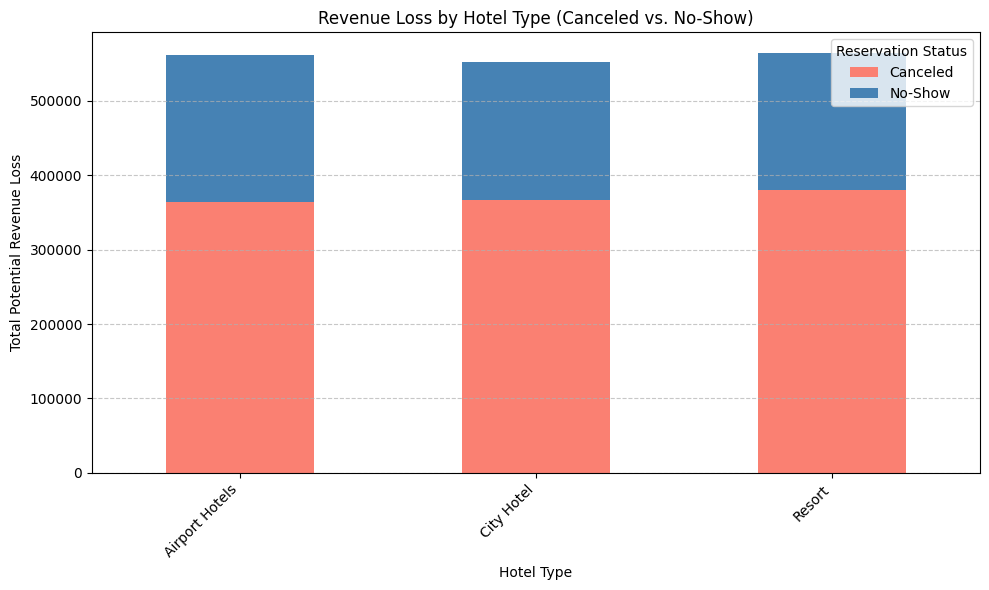

In [ ]:
# Calculate the sum of 'Potential_Revenue' for 'Canceled' and 'No-Show' reservations within each 'Hotel_Type'
lost_revenue_by_hotel_type = canceled_no_show_df.groupby(['Hotel_Type', 'Reservation_Status_Encoded'])['Potential_Revenue'].sum().unstack()

# Rename columns for better readability in the plot
lost_revenue_by_hotel_type.rename(columns={2: 'Canceled', 3: 'No-Show'}, inplace=True)

# Generate a stacked bar chart
plt.figure(figsize=(10, 6))
lost_revenue_by_hotel_type.plot(kind='bar', stacked=True, color={'Canceled': 'salmon', 'No-Show': 'steelblue'}, ax=plt.gca())

plt.title('Revenue Loss by Hotel Type (Canceled vs. No-Show)')
plt.xlabel('Hotel Type')
plt.ylabel('Total Potential Revenue Loss')
plt.xticks(rotation=45, ha='right')
plt.ticklabel_format(style='plain', axis='y') # Ensure y-axis tick labels are not in scientific notation

# Create a custom legend
handles, labels_plot = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['Canceled', 'No-Show'], title='Reservation Status')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# COMBINED ONES

# Deposit Type Vs Required Car Parking

In [ ]:
main_df['Booking_Deposit_Combo'] = main_df['Booking_channel'] + "_" + main_df['Deposit_type']

In [ ]:
main_df['Booking_Deposit_Combo']

,Booking_Deposit_Combo
0,Online_No Deposit
1,Direct_No Deposit
2,Online_No Deposit
3,Direct_Non-Refundable
4,Online_Refundable
...,...
22692,Online_No Deposit
22693,Agent_Refundable
22694,Direct_No Deposit
22695,Online_No Deposit


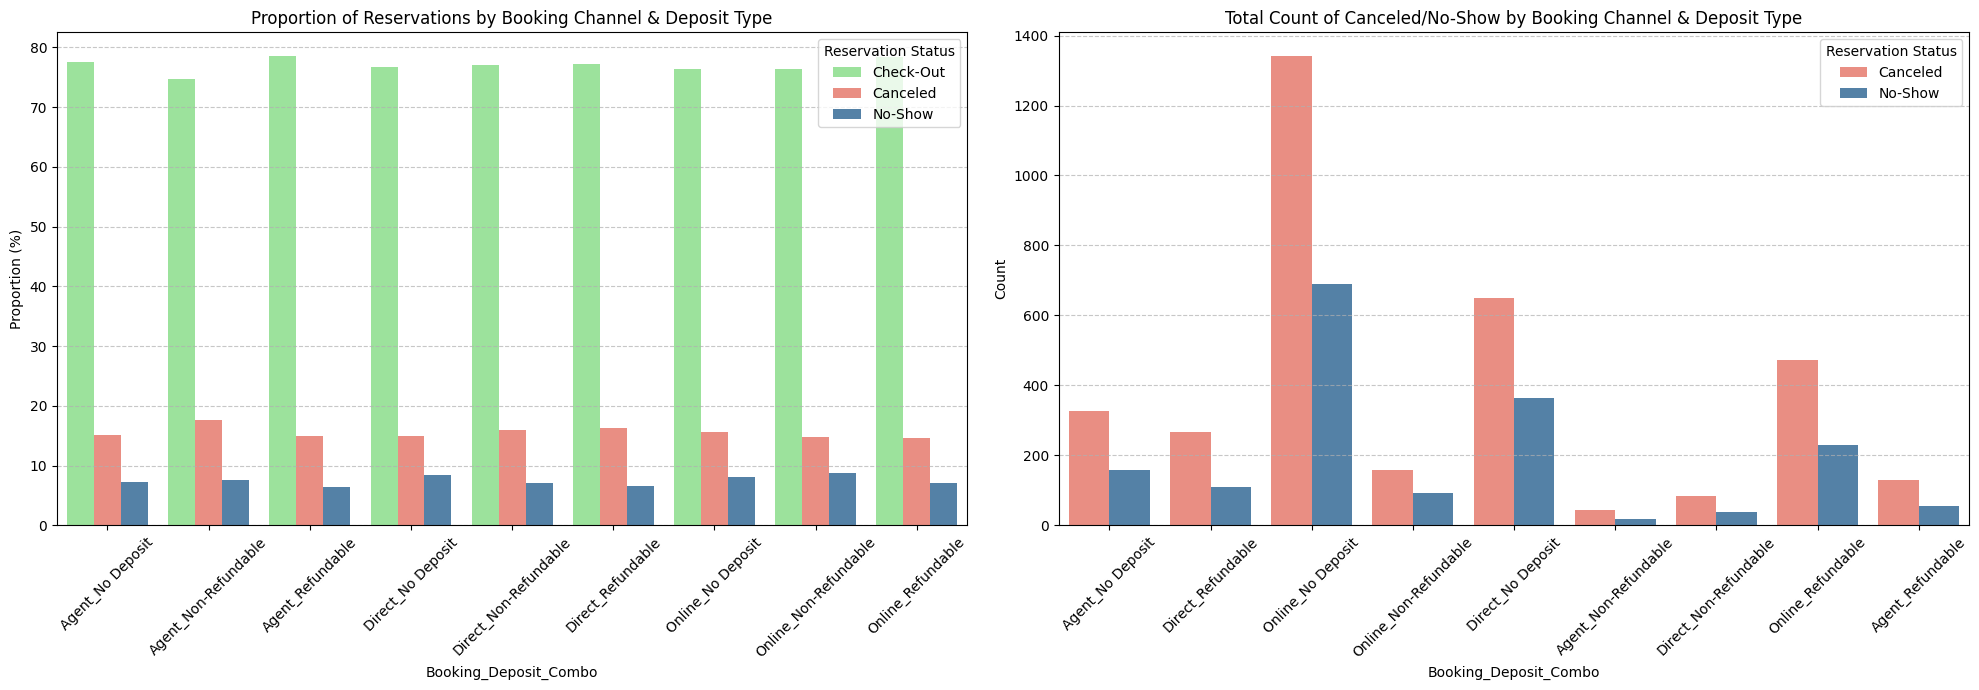

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare Proportion Data
status_combo_proportions = (
    main_df.groupby('Booking_Deposit_Combo')['Reservation_Status_Encoded']
    .value_counts(normalize=True)
    .mul(100)
    .rename('Proportion_Percentage')
    .reset_index()
)

# Filter canceled_no_show_df for the combined analysis
canceled_no_show_combo_df = main_df[main_df['Reservation_Status_Encoded'].isin([2, 3])].copy()
canceled_no_show_combo_df['Booking_Deposit_Combo'] = canceled_no_show_combo_df['Booking_channel'] + "_" + canceled_no_show_combo_df['Deposit_type']

# 2. Create the figure with 2 subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# --- PLOT 1: PROPORTIONS (Left) ---
sns.barplot(data=status_combo_proportions,
            x='Booking_Deposit_Combo',
            y='Proportion_Percentage',
            hue='Reservation_Status_Encoded',
            palette={1: 'lightgreen', 2: 'salmon', 3: 'steelblue'},
            ax=axes[0])

axes[0].set_title('Proportion of Reservations by Booking Channel & Deposit Type')
axes[0].set_ylabel('Proportion (%)')
axes[0].tick_params(axis='x', rotation=45)

# --- PLOT 2: RAW COUNTS (Right) ---
sns.countplot(data=canceled_no_show_combo_df,
              x='Booking_Deposit_Combo',
              hue='Reservation_Status_Encoded',
              palette={2: 'salmon', 3: 'steelblue'},
              ax=axes[1])

axes[1].set_title('Total Count of Canceled/No-Show by Booking Channel & Deposit Type')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

# 3. Uniform Legend Handling for both plots
new_labels_map = {1: 'Check-Out', 2: 'Canceled', 3: 'No-Show'}

for ax in axes:
    handles, labels = ax.get_legend_handles_labels()
    mapped_labels = [new_labels_map[int(float(label))] for label in labels]
    ax.legend(handles, mapped_labels, title='Reservation Status')
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Gender & Ethnicity

In [ ]:
main_df['Gender_Ethnicity_Combo'] = main_df['Gender'] + "_" + main_df['Ethnicity']

In [ ]:
main_df['Gender_Ethnicity_Combo']

,Gender_Ethnicity_Combo
0,F_Latino
1,F_Latino
2,M_Latino
3,M_African American
4,M_Latino
...,...
22692,F_African American
22693,F_Asian American
22694,F_Latino
22695,M_African American


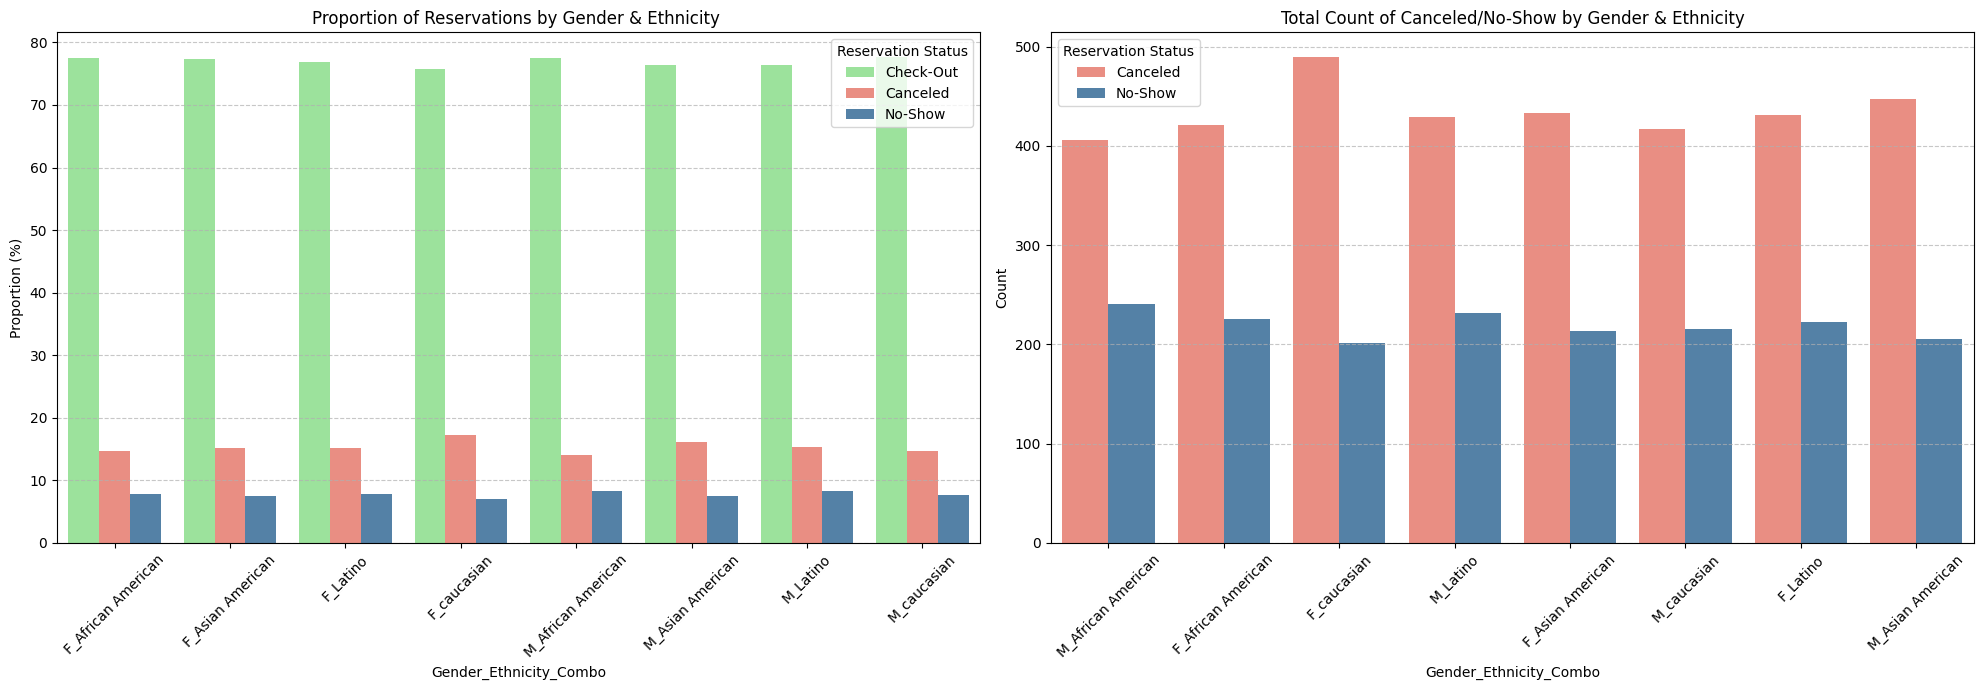

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare Proportion Data
status_combo_proportions = (
    main_df.groupby('Gender_Ethnicity_Combo')['Reservation_Status_Encoded']
    .value_counts(normalize=True)
    .mul(100)
    .rename('Proportion_Percentage')
    .reset_index()
)

# Filter canceled_no_show_df for the combined analysis
canceled_no_show_combo_df = main_df[main_df['Reservation_Status_Encoded'].isin([2, 3])].copy()
canceled_no_show_combo_df['Gender_Ethnicity_Combo'] = canceled_no_show_combo_df['Gender'] + "_" + canceled_no_show_combo_df['Ethnicity']

# 2. Create the figure with 2 subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# --- PLOT 1: PROPORTIONS (Left) ---
sns.barplot(data=status_combo_proportions,
            x='Gender_Ethnicity_Combo',
            y='Proportion_Percentage',
            hue='Reservation_Status_Encoded',
            palette={1: 'lightgreen', 2: 'salmon', 3: 'steelblue'},
            ax=axes[0])

axes[0].set_title('Proportion of Reservations by Gender & Ethnicity ')
axes[0].set_ylabel('Proportion (%)')
axes[0].tick_params(axis='x', rotation=45)

# --- PLOT 2: RAW COUNTS (Right) ---
sns.countplot(data=canceled_no_show_combo_df,
              x='Gender_Ethnicity_Combo',
              hue='Reservation_Status_Encoded',
              palette={2: 'salmon', 3: 'steelblue'},
              ax=axes[1])

axes[1].set_title('Total Count of Canceled/No-Show by Gender & Ethnicity')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

# 3. Uniform Legend Handling for both plots
new_labels_map = {1: 'Check-Out', 2: 'Canceled', 3: 'No-Show'}

for ax in axes:
    handles, labels = ax.get_legend_handles_labels()
    mapped_labels = [new_labels_map[int(float(label))] for label in labels]
    ax.legend(handles, mapped_labels, title='Reservation Status')
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# uSE PROMOTION AND ETHNICITY

In [ ]:
main_df['Promotion_Ethnicity_Combo'] = main_df['Use_Promotion'] + "_" + main_df['Ethnicity']


In [ ]:
main_df['Promotion_Ethnicity_Combo']

,Promotion_Ethnicity_Combo
0,Yes_Latino
1,Yes_Latino
2,No_Latino
3,Yes_African American
4,Yes_Latino
...,...
22692,Yes_African American
22693,Yes_Asian American
22694,Yes_Latino
22695,Yes_African American


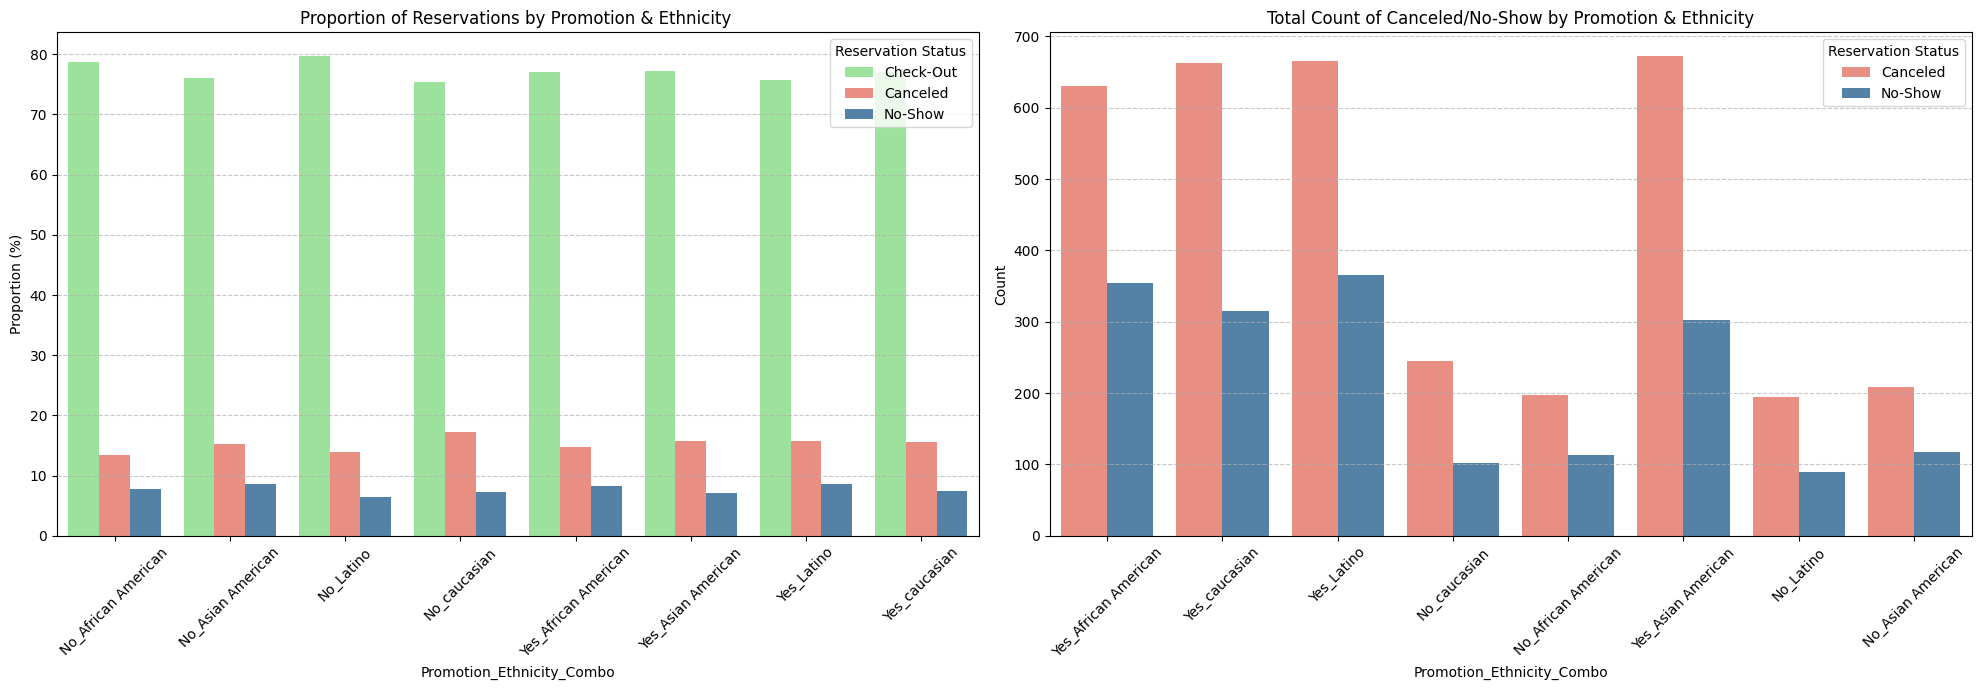

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare Proportion Data
status_combo_proportions = (
    main_df.groupby('Promotion_Ethnicity_Combo')['Reservation_Status_Encoded']
    .value_counts(normalize=True)
    .mul(100)
    .rename('Proportion_Percentage')
    .reset_index()
)

# Filter canceled_no_show_df for the combined analysis
canceled_no_show_combo_df = main_df[main_df['Reservation_Status_Encoded'].isin([2, 3])].copy()
canceled_no_show_combo_df['Promotion_Ethnicity_Combo'] = canceled_no_show_combo_df['Use_Promotion'] + "_" + canceled_no_show_combo_df['Ethnicity']

# 2. Create the figure with 2 subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# --- PLOT 1: PROPORTIONS (Left) ---
sns.barplot(data=status_combo_proportions,
            x='Promotion_Ethnicity_Combo',
            y='Proportion_Percentage',
            hue='Reservation_Status_Encoded',
            palette={1: 'lightgreen', 2: 'salmon', 3: 'steelblue'},
            ax=axes[0])

axes[0].set_title('Proportion of Reservations by Promotion & Ethnicity ')
axes[0].set_ylabel('Proportion (%)')
axes[0].tick_params(axis='x', rotation=45)

# --- PLOT 2: RAW COUNTS (Right) ---
sns.countplot(data=canceled_no_show_combo_df,
              x='Promotion_Ethnicity_Combo',
              hue='Reservation_Status_Encoded',
              palette={2: 'salmon', 3: 'steelblue'},
              ax=axes[1])

axes[1].set_title('Total Count of Canceled/No-Show by Promotion & Ethnicity')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

# 3. Uniform Legend Handling for both plots
new_labels_map = {1: 'Check-Out', 2: 'Canceled', 3: 'No-Show'}

for ax in axes:
    handles, labels = ax.get_legend_handles_labels()
    mapped_labels = [new_labels_map[int(float(label))] for label in labels]
    ax.legend(handles, mapped_labels, title='Reservation Status')
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()